In [16]:
import windrose
from windrose import WindroseAxes
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import numpy as np
import mpl_toolkits
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import netCDF4 as nc
import metpy
import metpy.calc as mpcalc
from metpy.units import units, pandas_dataframe_to_unit_arrays
from metpy.plots import ImagePlot, MapPanel, PanelContainer
from metpy.calc import wind_components
from metpy.interpolate import cross_section
from scipy.constants import convert_temperature
import xarray as xr
import math
import matplotlib
import os
import plotly
# import proplot
import plotly.express as px
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import proplot as pplt
import logging
from rich.logging import RichHandler
from rich.traceback import install

install()

notebook_dir =os.getcwd()
root_dir=os.path.abspath(os.path.join(notebook_dir,'..'))
data_dir=os.path.join(root_dir,'data')
shape_dir=os.path.join(data_dir,'shapefiles')
mask_dir=os.path.join(root_dir,'masks')

fish_lake_file=os.path.join(mask_dir, 'FishLa')
#/Users/meghan/Roza/roza3/roza/masks/FishLake.nc


np.set_printoptions(linewidth=500)
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

logging.basicConfig(
    level=os.environ.get('DORN_LOGLEVEL', 'INFO'), 
    format=" [%(name)s] :: %(message)s", 
    datefmt="[%X] ", 
    handlers=[RichHandler()])




In [9]:
try:
    import IPython
    __file__ = IPython.extract_module_locals()[1]["__vsc_ipynb_file__"]
    root_dir = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except (AttributeError, ImportError, KeyError):
    root_dir = os.path.abspath("../")

data_root = os.path.join(root_dir, 'applied_masks')
output_path = os.path.join(root_dir, 'figures', 'windroses')

In [34]:
#Data Files
airfiles=[
    {'filepath':os.path.join(data_root, 'FishLake.nc'),'name':'Airborne: Fish Lake 700MB Winds'},
    {'filepath':os.path.join(data_root, 'BurntMountain.nc'),'name':'Airborne: Burnt Mountain 700MB Winds'},
    {'filepath':os.path.join(data_root, 'CorralPass.nc'),'name':'Airborne: Corral Pass 700MB Winds'},
    {'filepath':os.path.join(data_root, 'SkateCreek.nc'),'name':'Airborne: Skate Creek 700MB Winds'},
    {'filepath':os.path.join(data_root, 'CayusePass.nc'),'name':'Airborne: Cayuse Pass 700MB Winds'},
    {'filepath':os.path.join(data_root, 'MeadowsPass.nc'),'name':'Airborne: Meadows Pass 700MB Winds'},
    {'filepath':os.path.join(data_root, 'SasseRidge.nc'),'name':'Airborne: Sasse Ridge 700MB Winds'},

    ]

In [35]:
#Data Files
groundfiles=[
    
    {'filepath':os.path.join(data_root, 'FishLake.nc'),'name':'Ground-based Fish Lake 700MB Winds'},
    {'filepath':os.path.join(data_root, 'BurntMountain.nc'),'name':'Ground-based: Burnt Mountain 700MB Winds'},
    {'filepath':os.path.join(data_root, 'CorralPass.nc'),'name':'Ground-based: Corral Pass 700MB Winds'},
    {'filepath':os.path.join(data_root, 'SkateCreek.nc'),'name':'Ground-based: Skate Creek 700MB Winds'},
    {'filepath':os.path.join(data_root, 'CayusePass.nc'),'name':'Ground-based: Cayuse Pass 700MB Winds'},
    {'filepath':os.path.join(data_root, 'MeadowsPass.nc'),'name':'Ground-based: Meadows Pass 700MB Winds'},
    {'filepath':os.path.join(data_root, 'SasseRidge.nc'),'name':'Ground-based: Sasse Ridge 700MB Winds'},
 
    ]

Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/airslw_windrose/Airborne_Fish_Lake_700MB_Winds_Windrose.png"


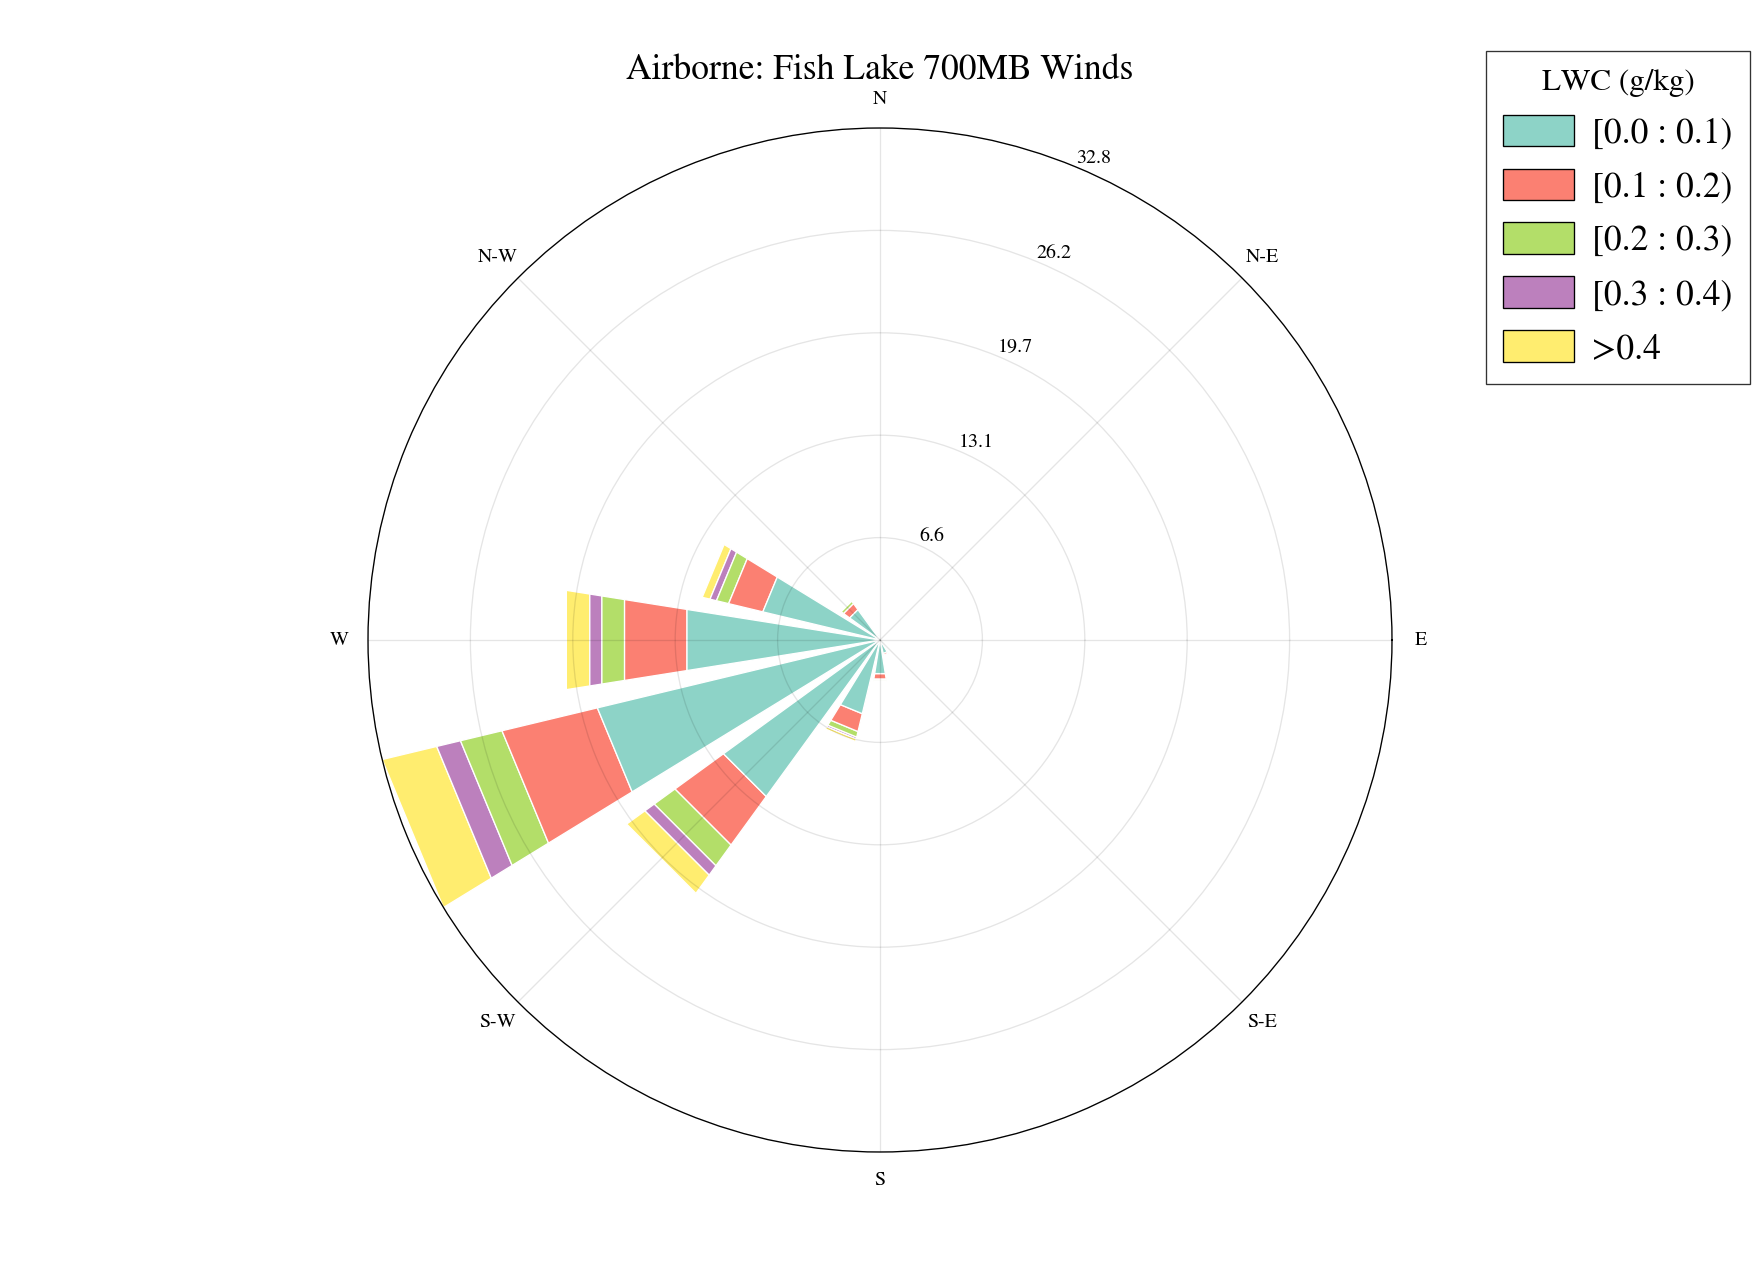

Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/airslw_windrose/Airborne_Burnt_Mountain_700MB_Winds_Windrose.png"


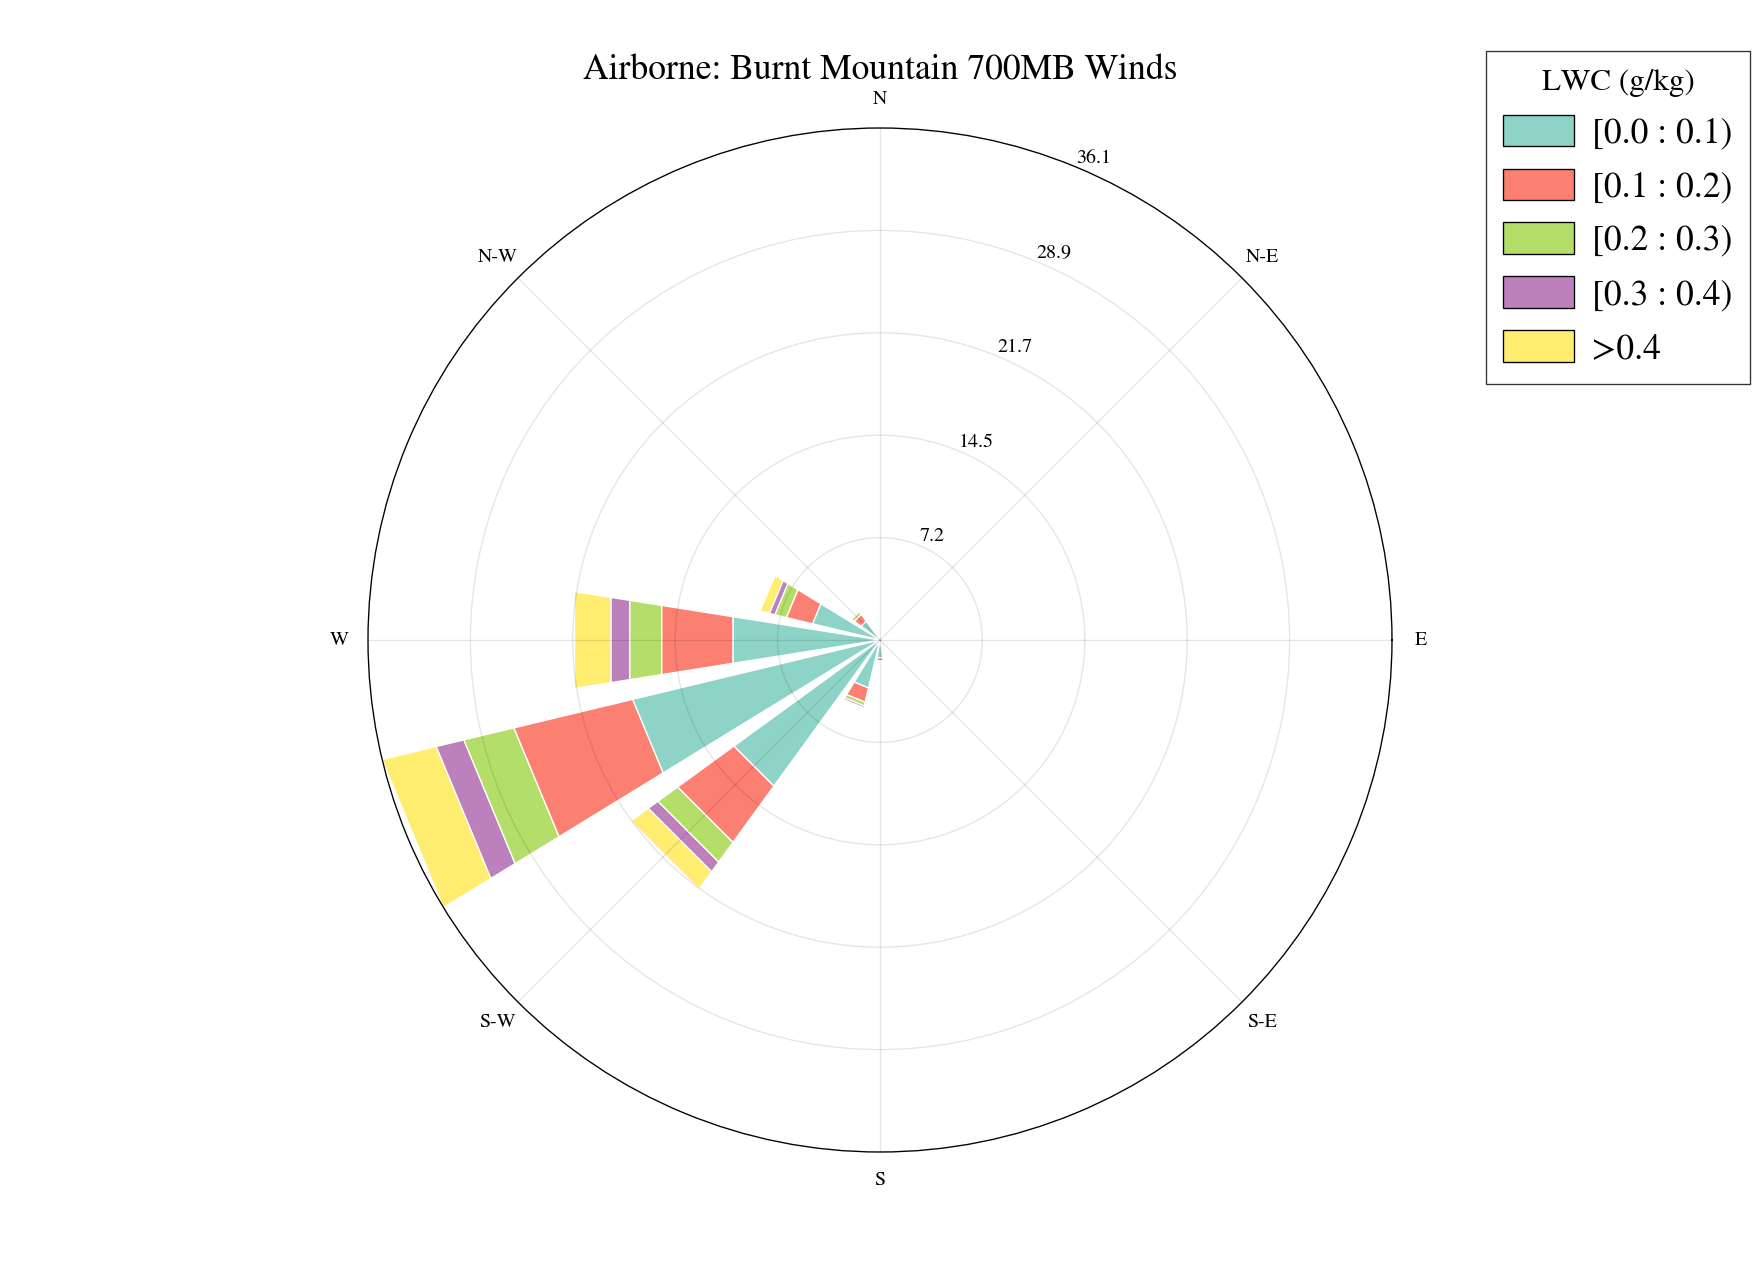

Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/airslw_windrose/Airborne_Corral_Pass_700MB_Winds_Windrose.png"


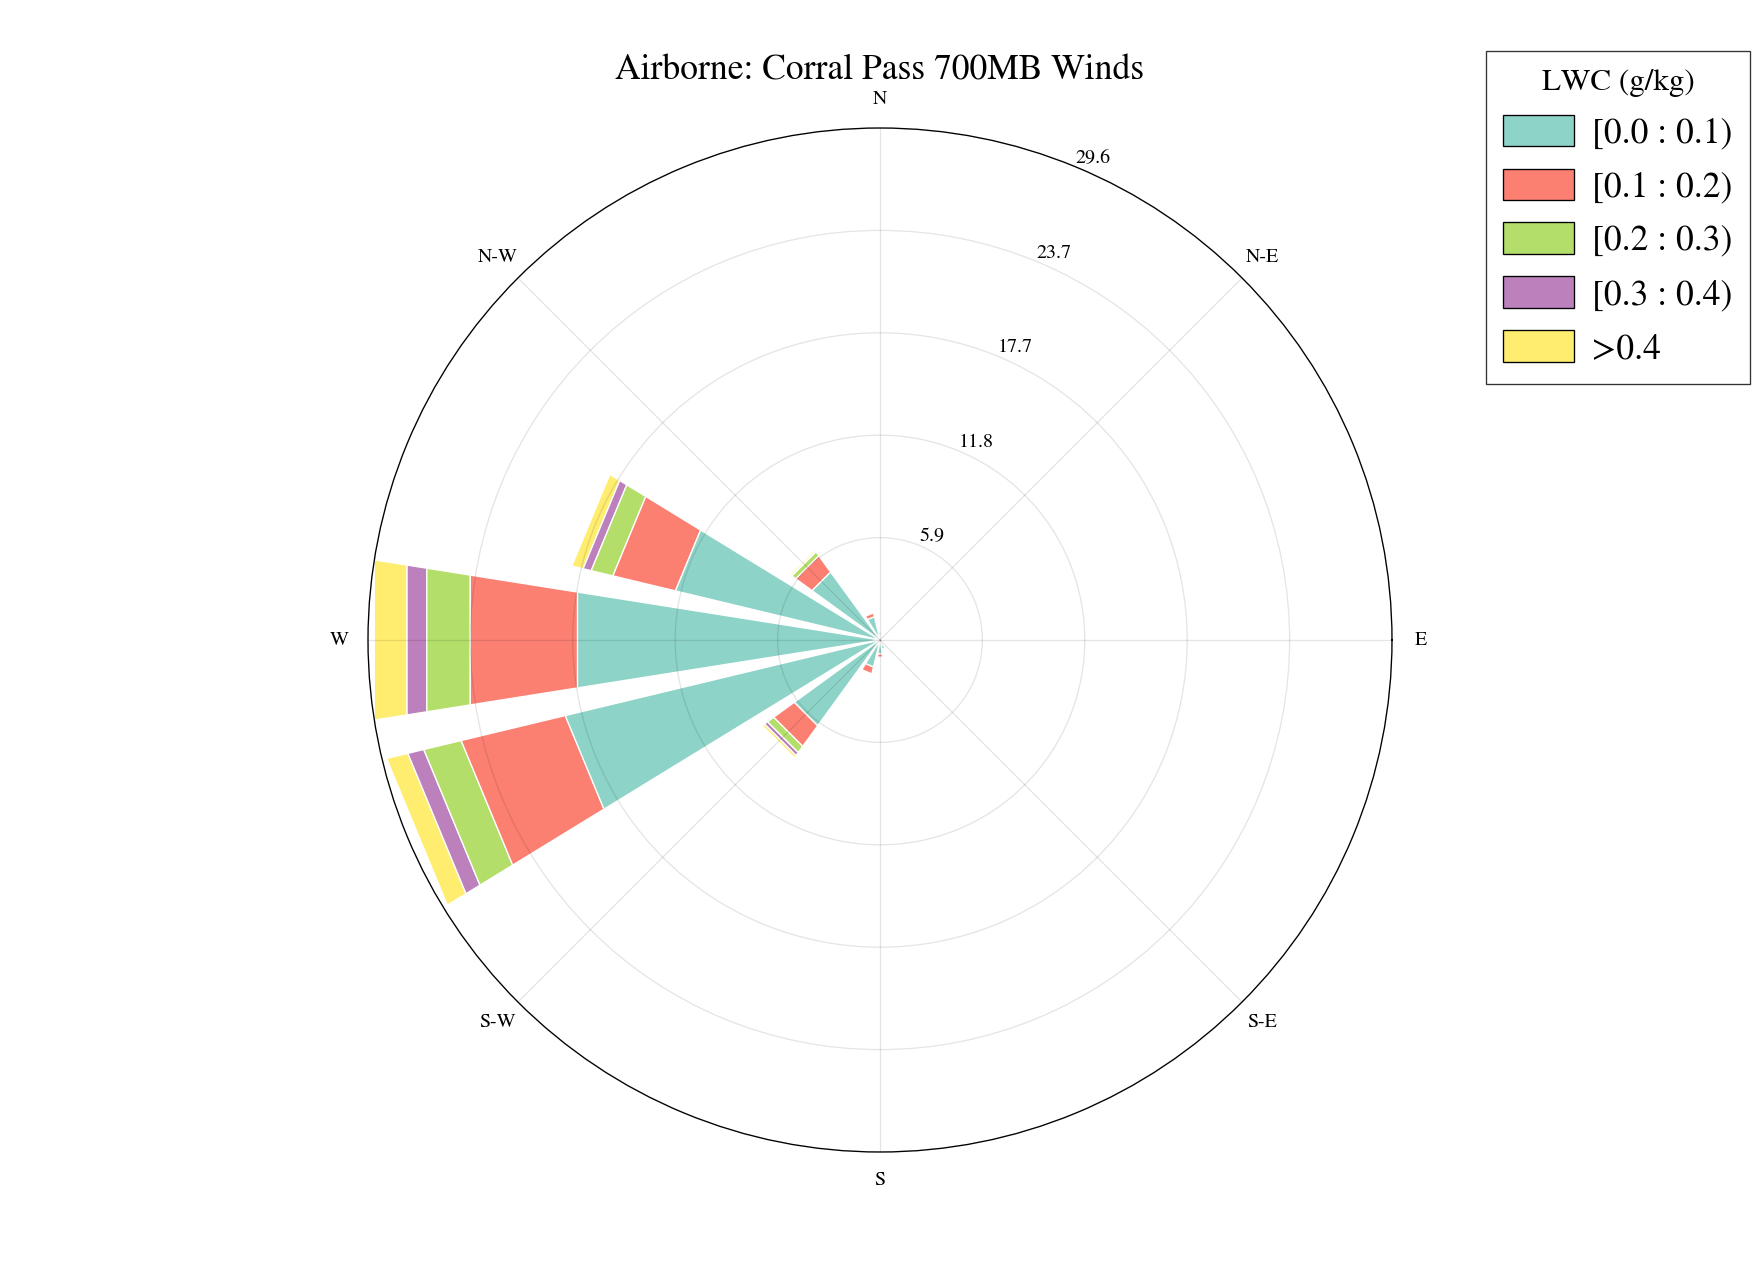

Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/airslw_windrose/Airborne_Skate_Creek_700MB_Winds_Windrose.png"


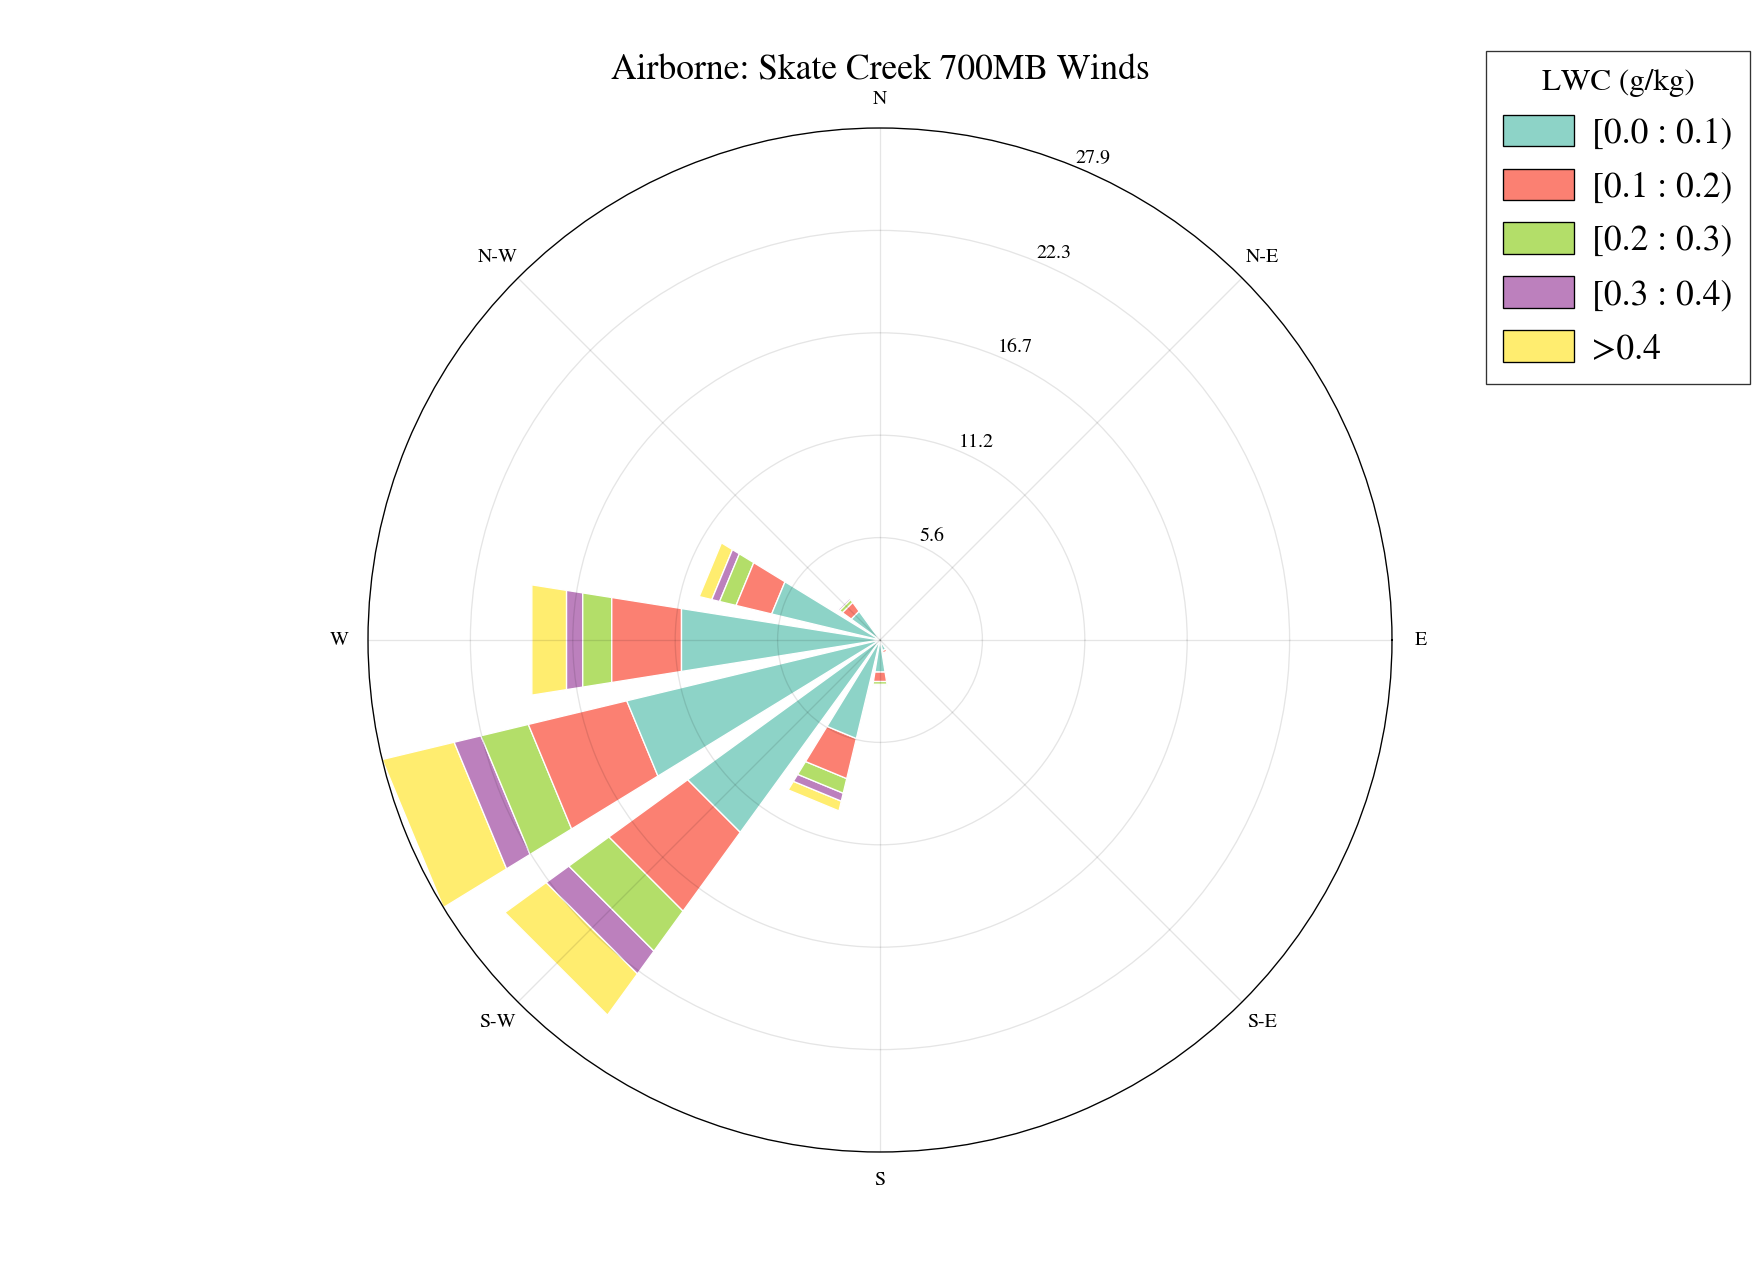

Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/airslw_windrose/Airborne_Cayuse_Pass_700MB_Winds_Windrose.png"


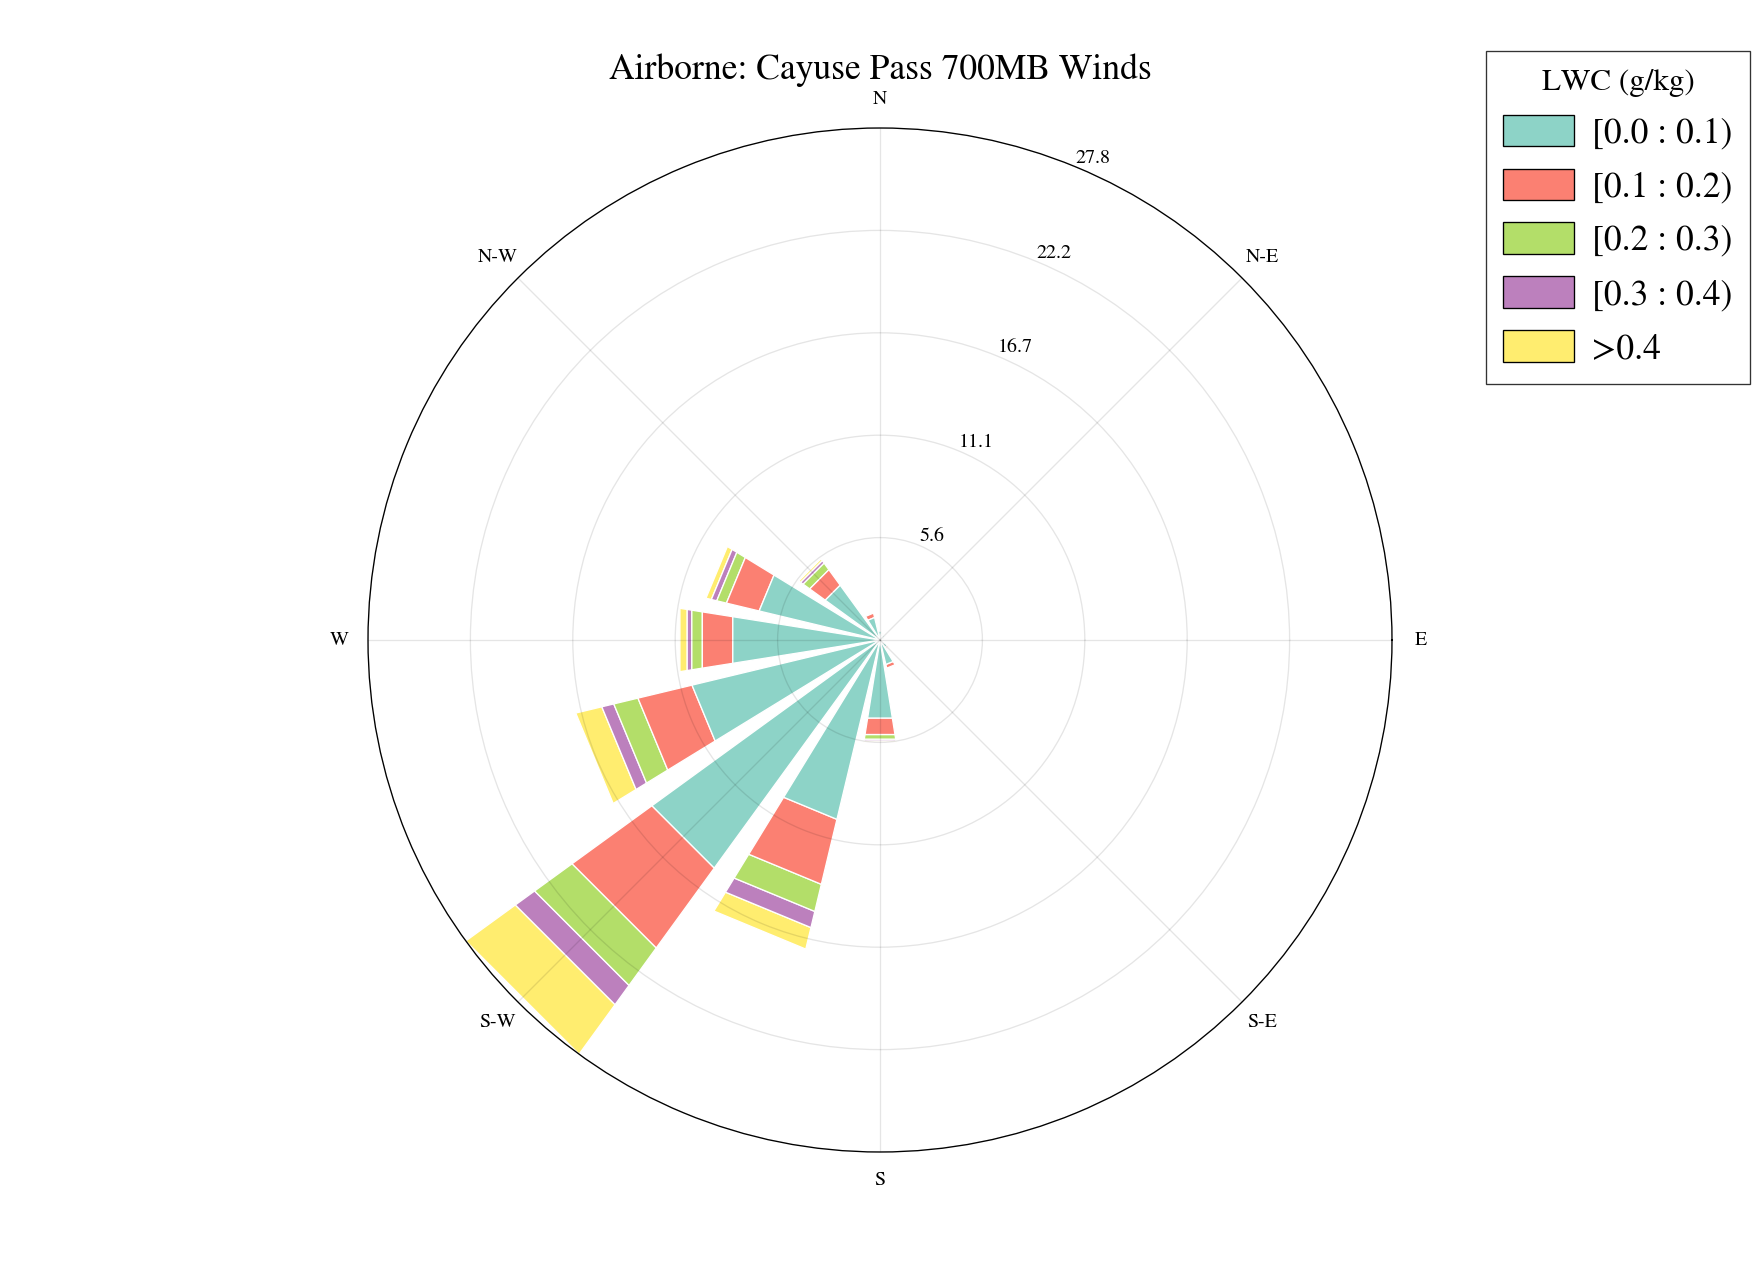

Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/airslw_windrose/Airborne_Meadows_Pass_700MB_Winds_Windrose.png"


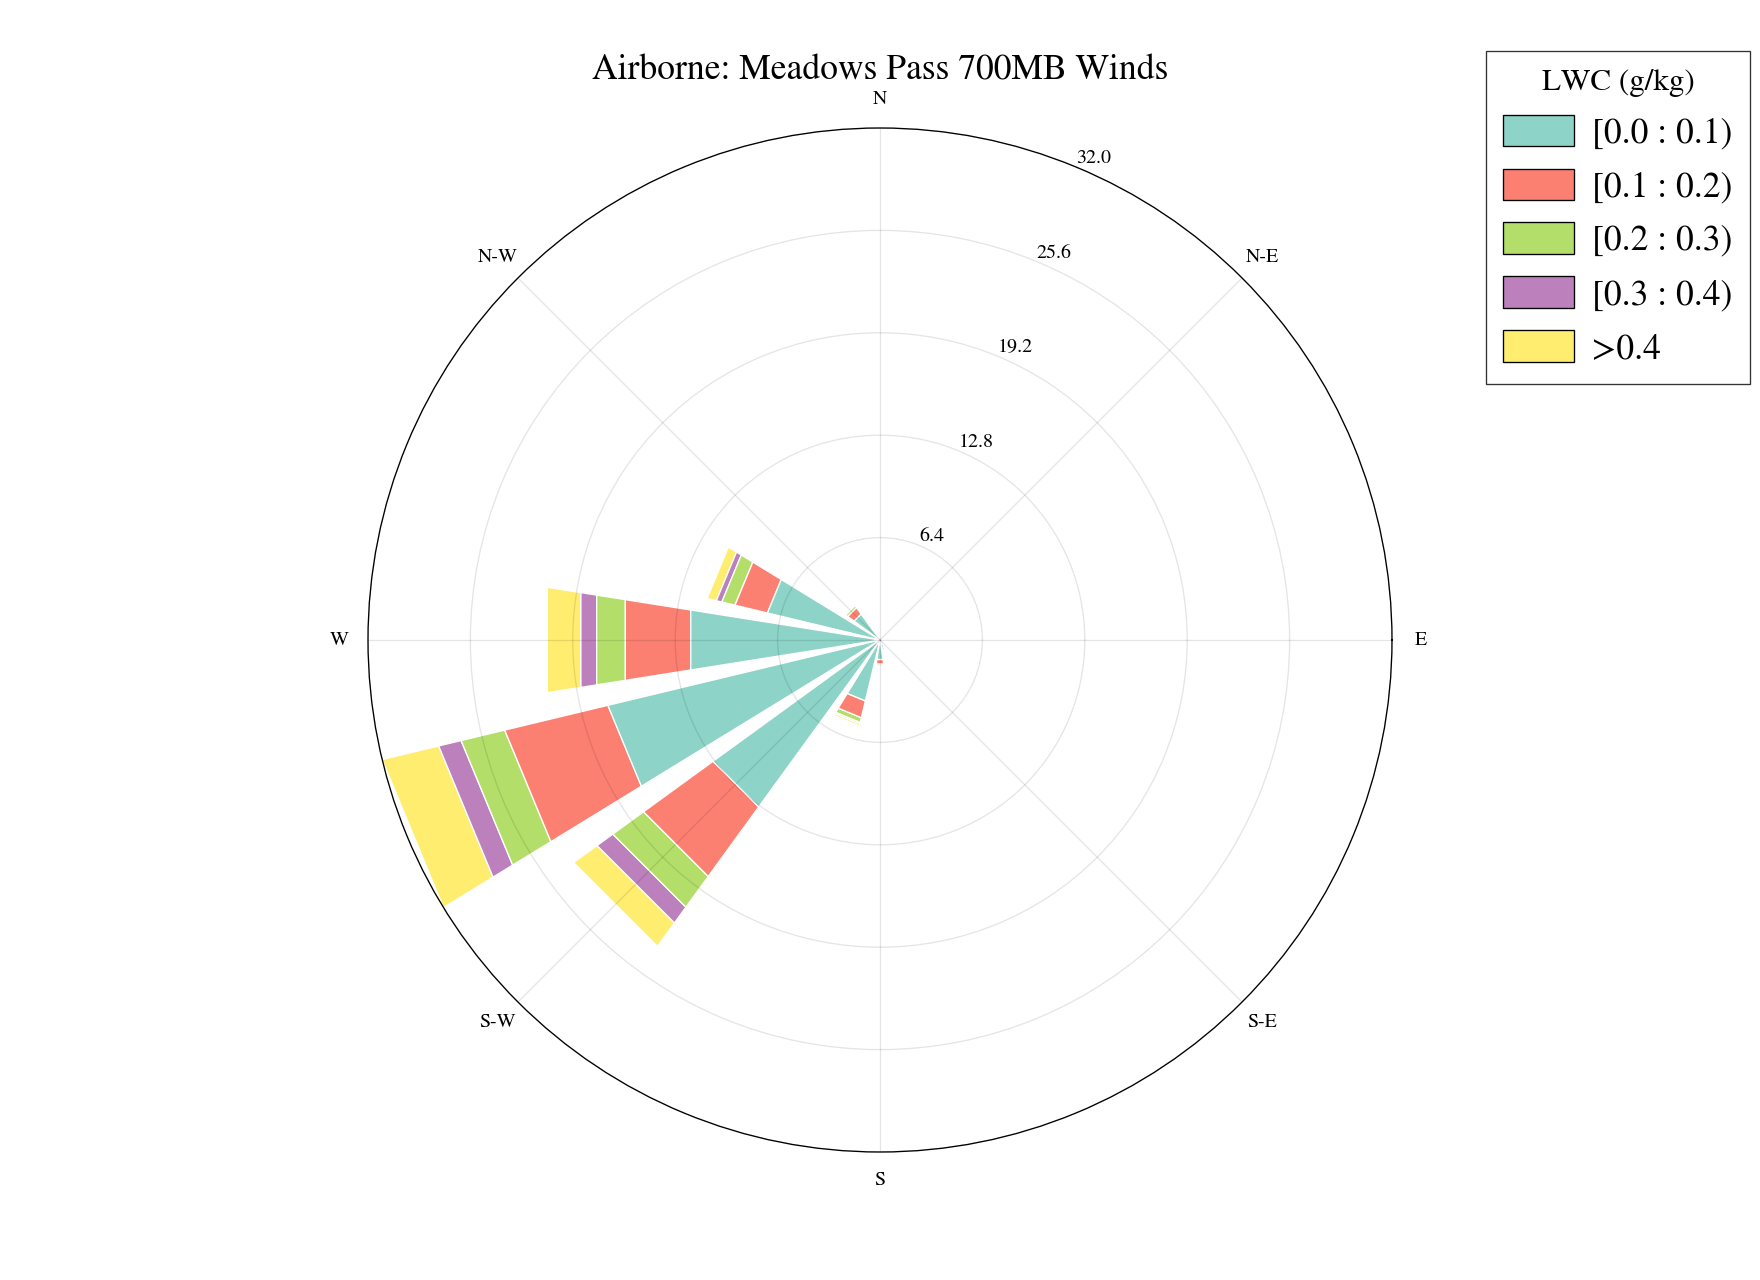

Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/airslw_windrose/Airborne_Sasse_Ridge_700MB_Winds_Windrose.png"


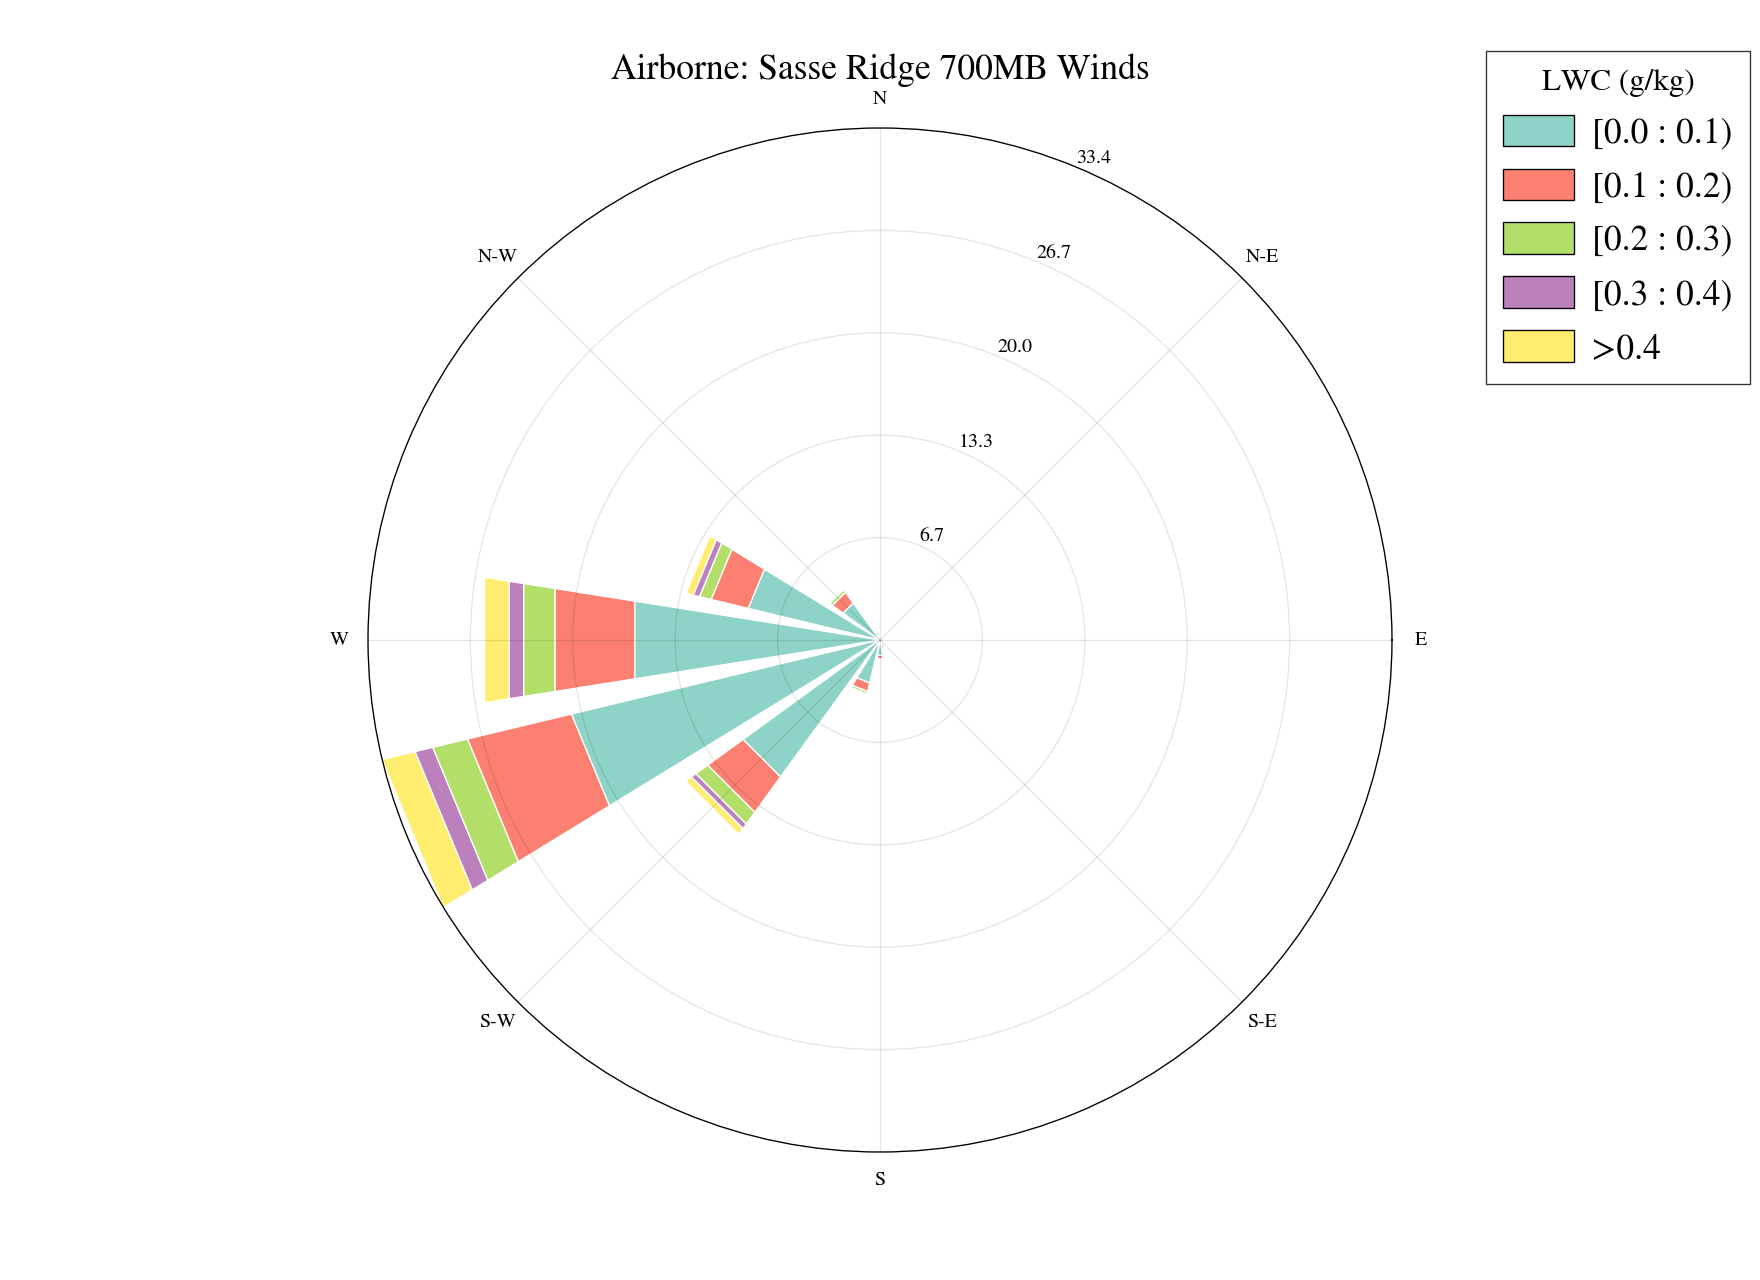

In [36]:
#Plot windroses by SLW - Airborne
def airslw_windrose(filepath=None, name=None):
    filepath = filepath if os.path.exists(filepath) else os.path.join('windrose_data', filepath)
    ds = xr.open_dataset(filepath, engine = 'netcdf4')
    df = ds[['U_700MB','V_700MB','AS_LWC']].to_dataframe()
    df=df[df['AS_LWC']>0.01]
    df.U_700MB[df.U_700MB > 999] = np.nan
    df.V_700MB[df.V_700MB > 999] = np.nan
    df['WSPD'] = np.sqrt(df.U_700MB**2+df.V_700MB**2)
    df['WDIR'] = np.arctan2(df.U_700MB.values,df.V_700MB.values)*180/math.pi+180;
    df.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    speed =df.WSPD
    dir = df.WDIR
    LWC=df.AS_LWC

    # colormap = plt.get_cmap('batlow')
    colormap = plt.get_cmap('set3')
    ax = WindroseAxes.from_ax()
    # ax.set_xticklabels(['N','NE','E','SE','S','SW','W','NW'],fontsize=14)
    # ax.set_yticklabels([],fontsize=14)
    ax.bar(df.WDIR,df.AS_LWC, normed = True, opening=0.8, edgecolor='white', bins = np.arange(0,.5,0.1),cmap = colormap)

    
    ax.set_legend()
    ax.set_title(name, fontsize=16)
    ax.legend(title='LWC (g/kg)',loc = 4, bbox_to_anchor=[1.35, 0.75],fontsize=16, title_fontsize=14)
    

    # ax.set_yticks(np.arange(10, 40, step=10))
    # ax.set_yticklabels(np.arange(10, 40, step=10))
    fig = plt.gcf()
    fig.set_size_inches(11, 8)
    output_name="{}_Windrose.png".format(name.replace('-','_').replace(':','').replace('(','').replace(')','').replace(' ','_'))
    output_file=os.path.join(output_path, 'airslw_windrose', output_name)
    print(f'Saving windrose image to: "{output_file}"')
    matplotlib.pyplot.savefig(output_file, dpi=300, transparent=False)
    # matplotlib.pyplot.close()
    matplotlib.pyplot.show()
    
_=[airslw_windrose(**dd) for dd in airfiles]



In [31]:
#Plot windroses by SLW - Airborne - No labels
def SLW_windrose(filepath=None, name=None):
    filepath = filepath if os.path.exists(filepath) else os.path.join('windrose_data', filepath)
    ds = xr.open_dataset(filepath, engine = 'netcdf4')
    df = ds[['U_700MB','V_700MB','AS_LWC']].to_dataframe()
    df=df[df['AS_LWC']>0.01]
    df.U_700MB[df.U_700MB > 999] = np.nan
    df.V_700MB[df.V_700MB > 999] = np.nan
    df['WSPD'] = np.sqrt(df.U_700MB**2+df.V_700MB**2)
    df['WDIR'] = np.arctan2(df.U_700MB.values,df.V_700MB.values)*180/math.pi+180;
    df.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    speed =df.WSPD
    dir = df.WDIR

    colormap = plt.get_cmap('glacial')
    ax = WindroseAxes.from_ax()
    ax.bar(df.WDIR,df.WSPD, normed = True, opening=0.8, edgecolor='white', bins = 10,cmap = colormap)

    
    #ax.set_legend()
    ax.set_title(name)
    #ax.legend(title='Wind Speed (m/s)) with SLW - Airborne',loc = 4)

    # ax.set_yticks(np.arange(10, 40, step=10))
    # ax.set_yticklabels(np.arange(10, 40, step=10))

    #matplotlib.pyplot.savefig(os.path.join('precip_windrose',"{} Precip Windrose.png".format(name.replace(' ','_'))), dpi=300, transparent=False)
    #matplotlib.pyplot.close()
    matplotlib.pyplot.show()
    
# _=[SLW_windrose(**dd) for dd in files]



Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/groundslw_windrose/Ground_based_Fish_Lake_700MB_Winds_Windrose.png"


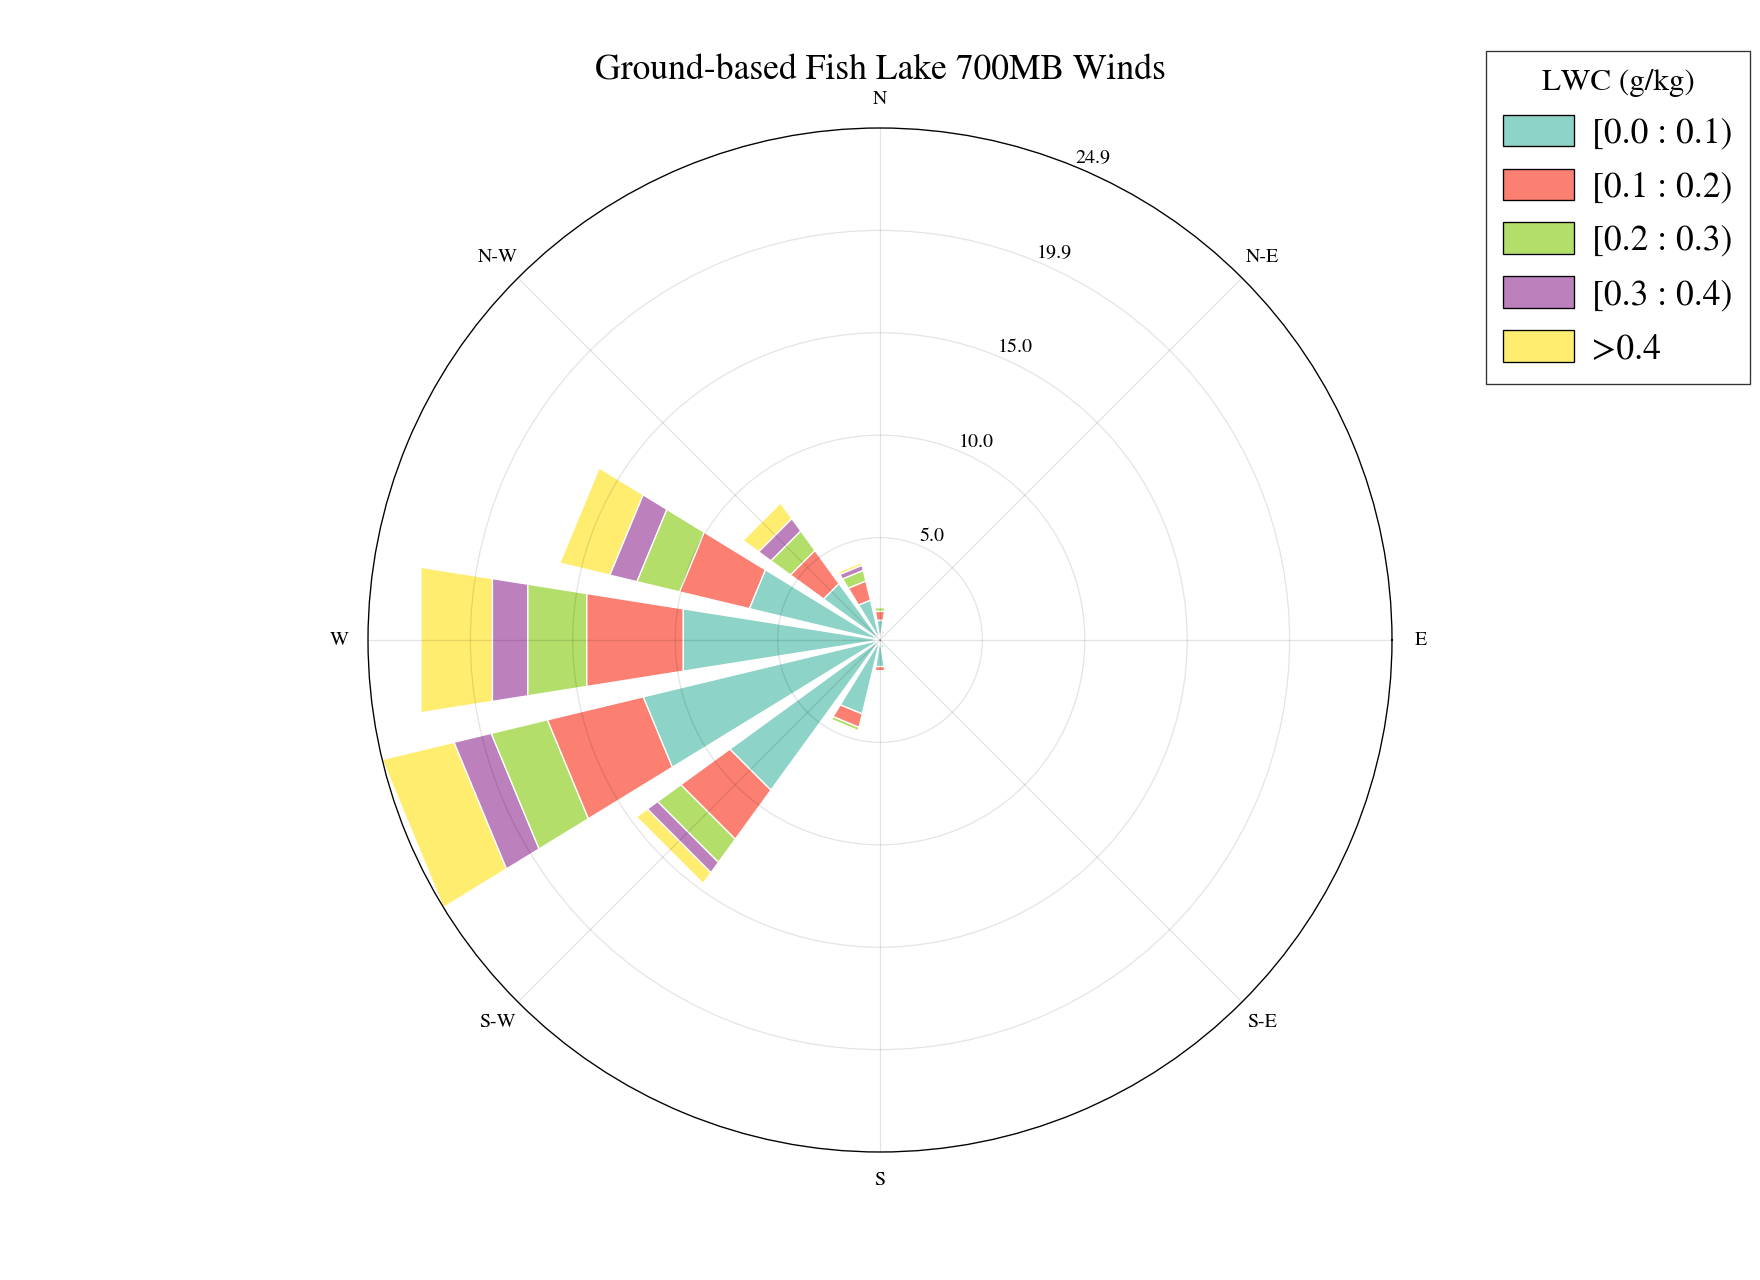

Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/groundslw_windrose/Ground_based_Burnt_Mountain_700MB_Winds_Windrose.png"


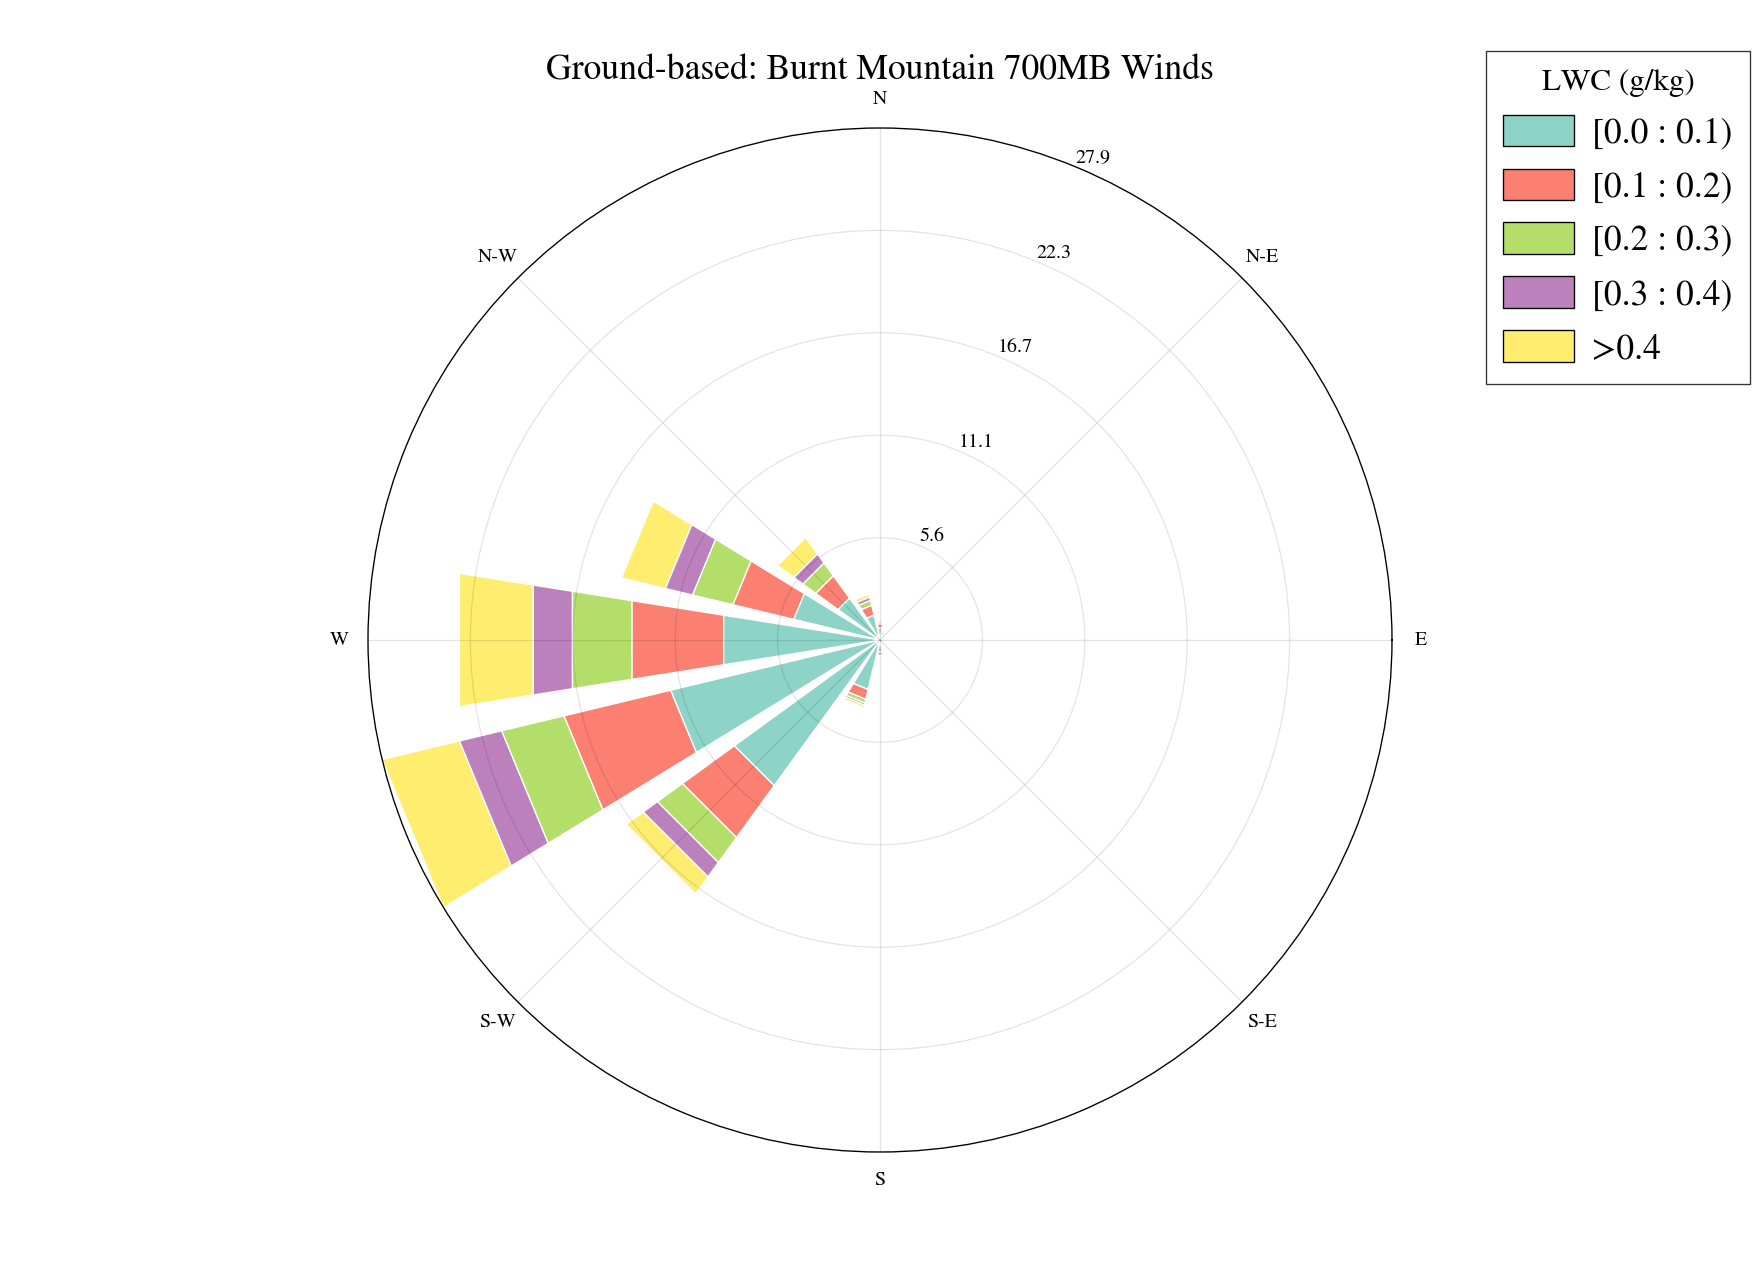

Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/groundslw_windrose/Ground_based_Corral_Pass_700MB_Winds_Windrose.png"


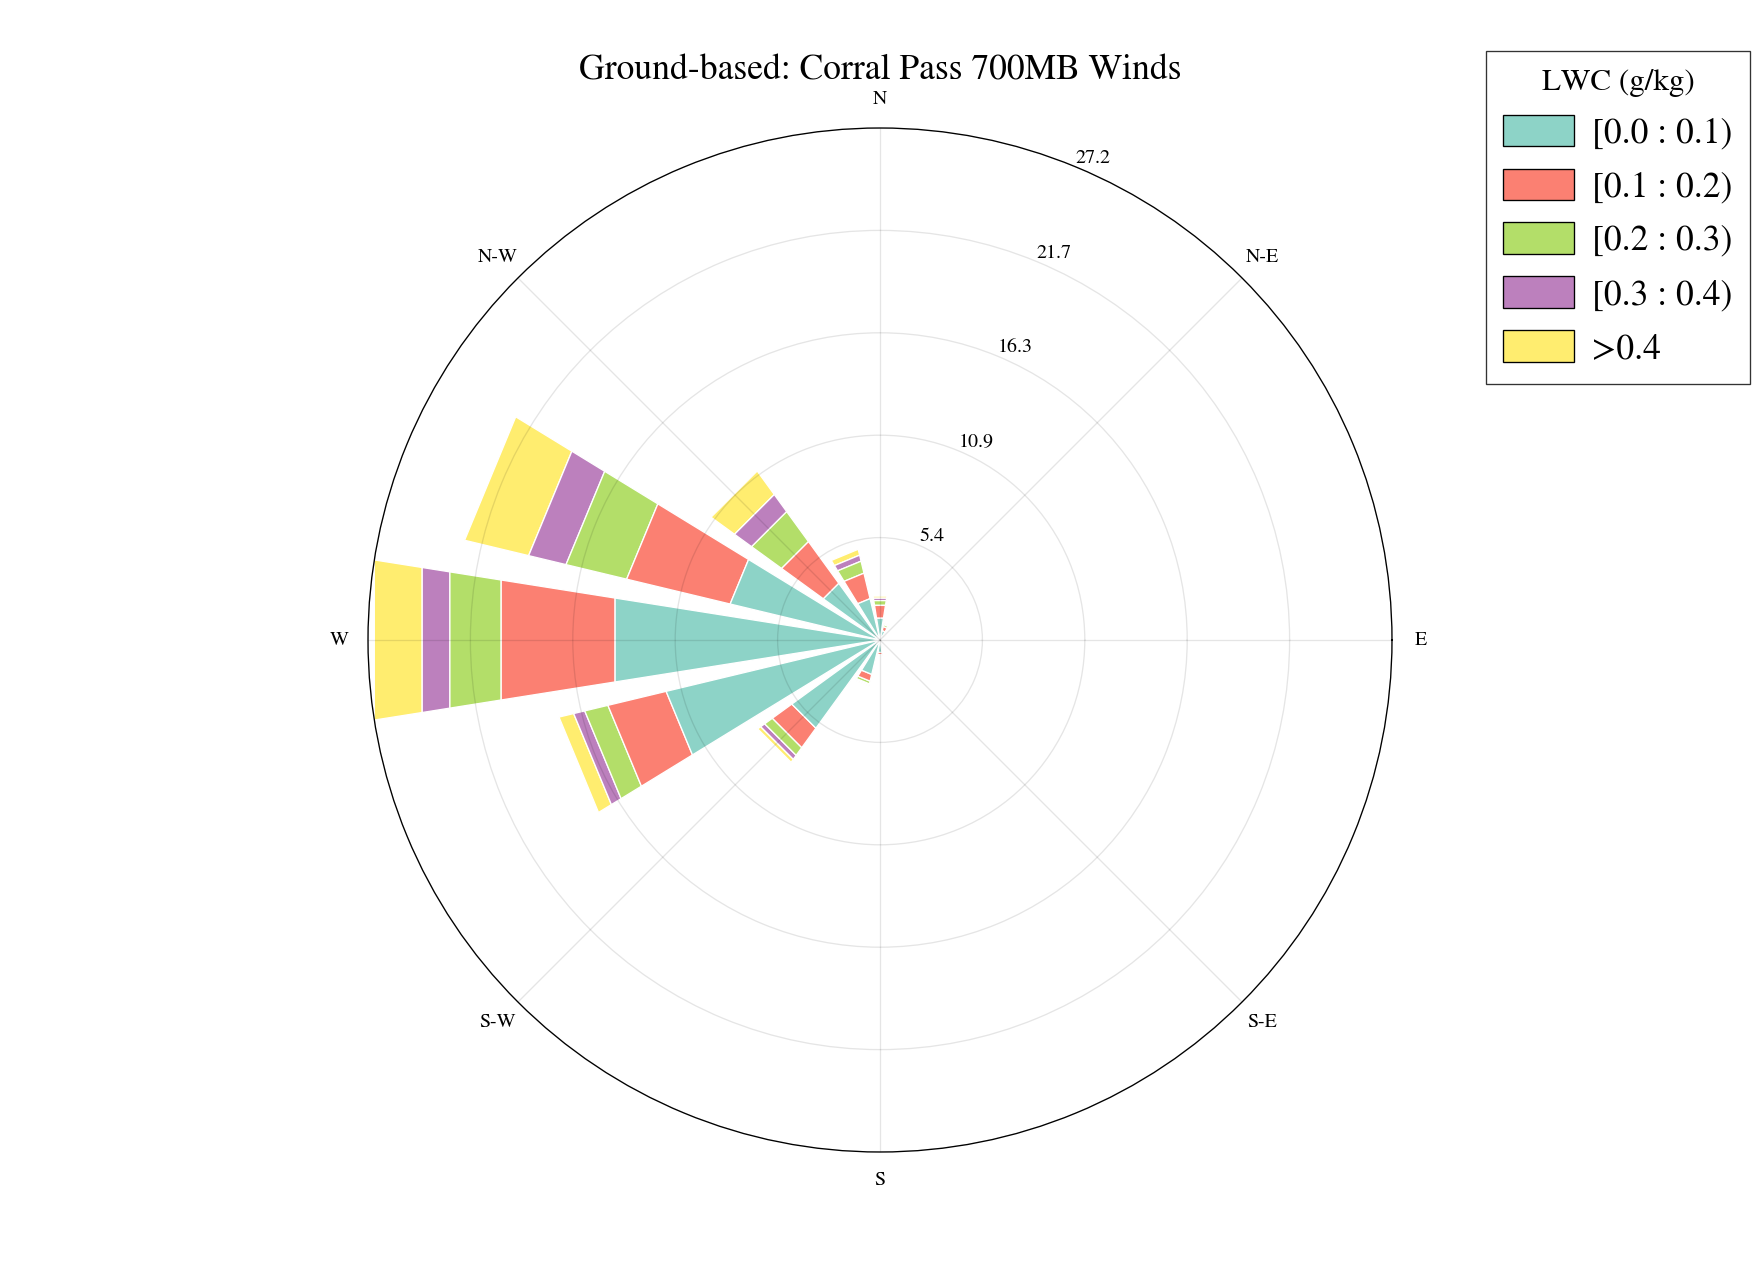

Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/groundslw_windrose/Ground_based_Skate_Creek_700MB_Winds_Windrose.png"


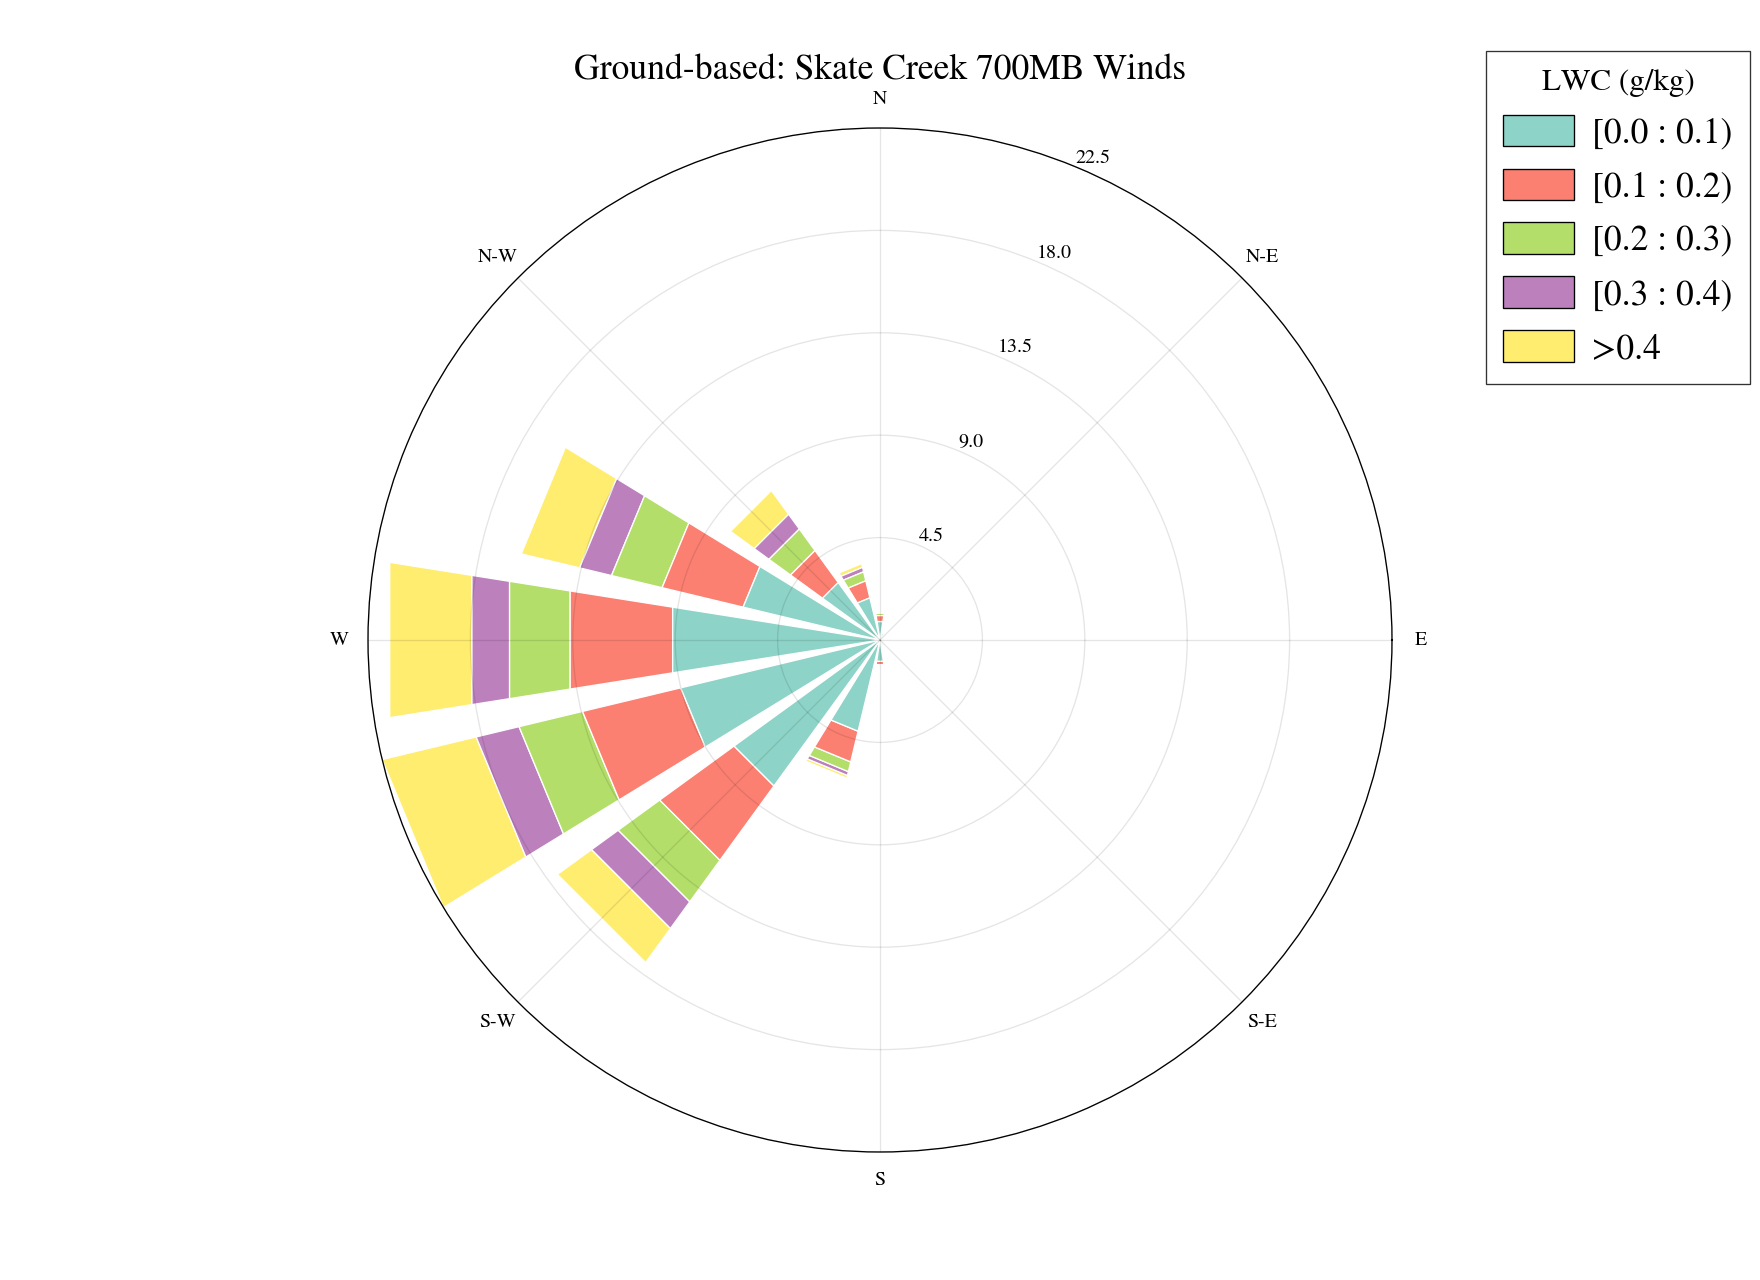

Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/groundslw_windrose/Ground_based_Cayuse_Pass_700MB_Winds_Windrose.png"


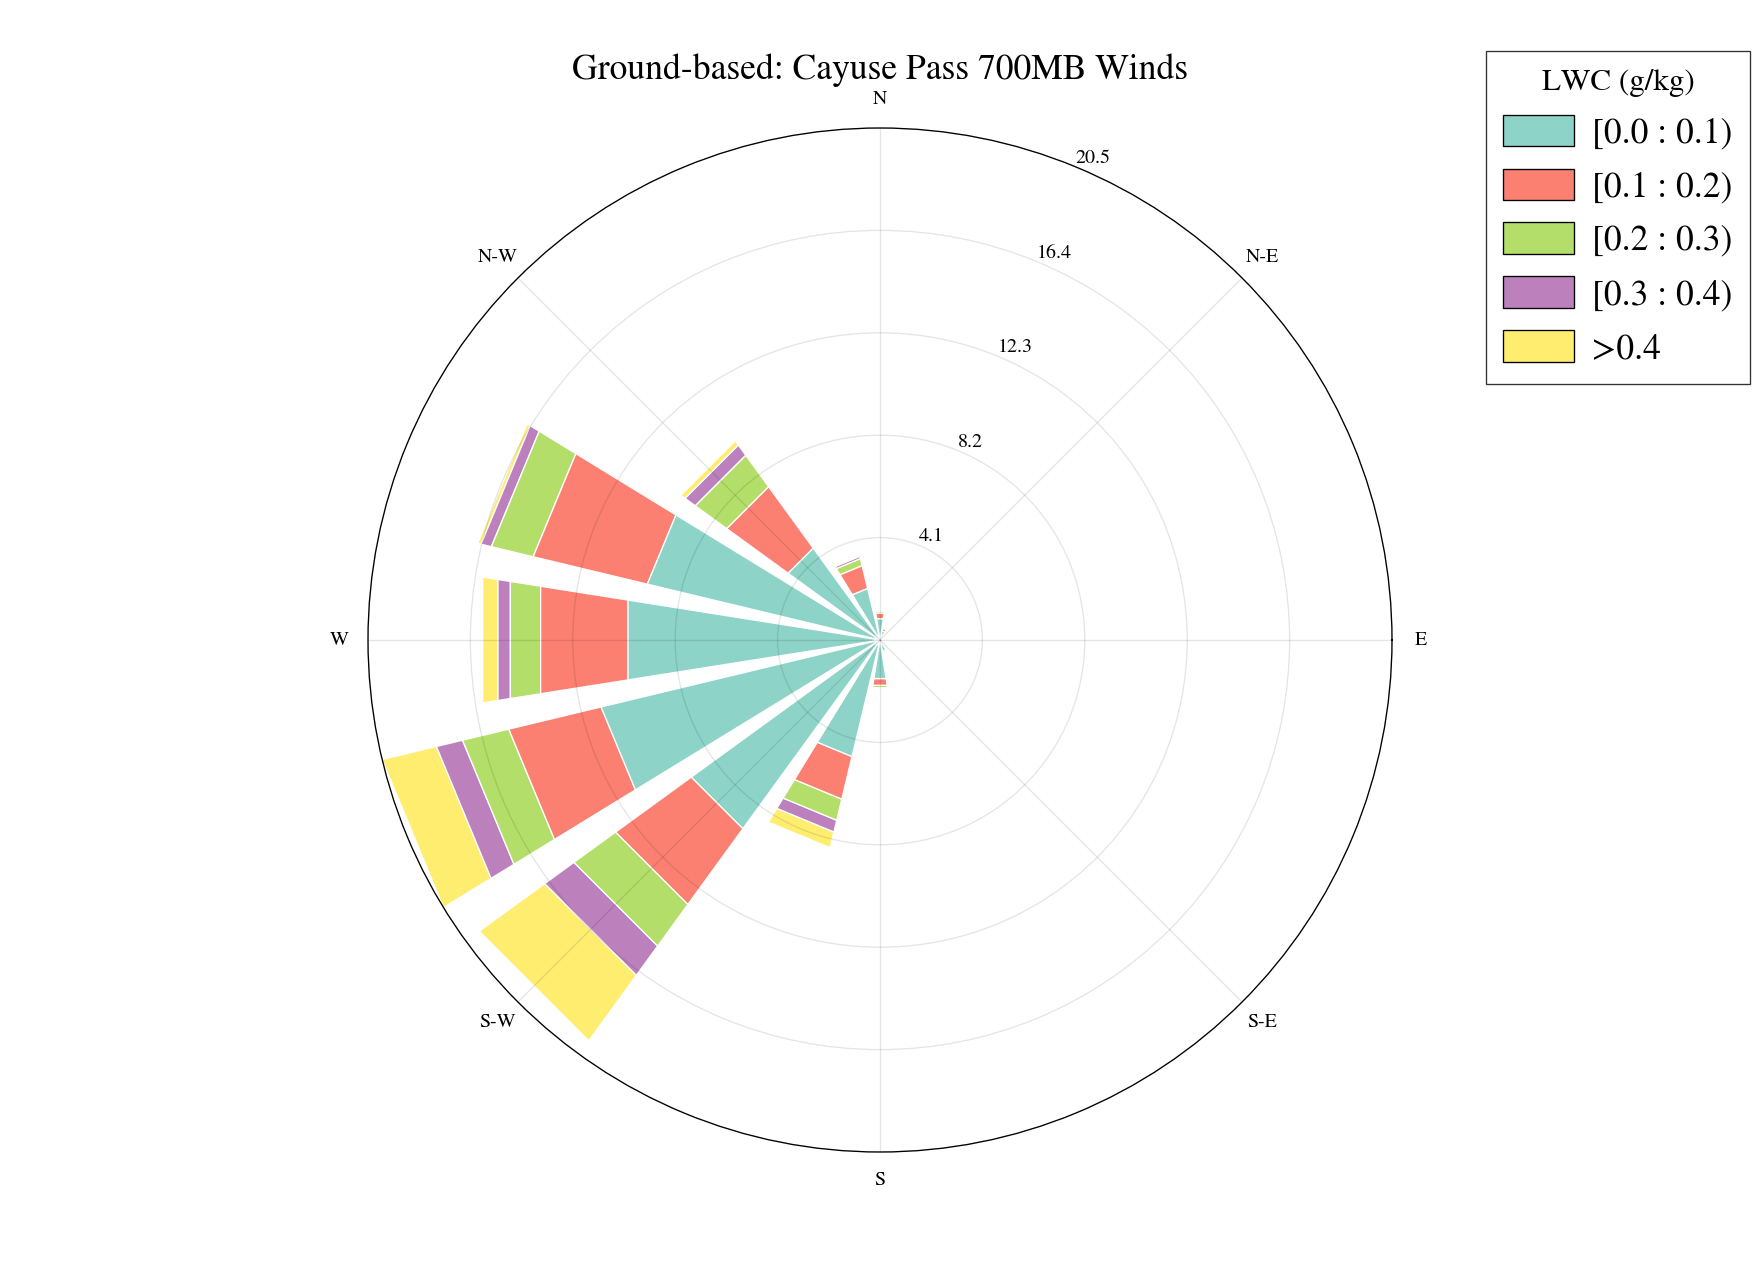

Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/groundslw_windrose/Ground_based_Meadows_Pass_700MB_Winds_Windrose.png"


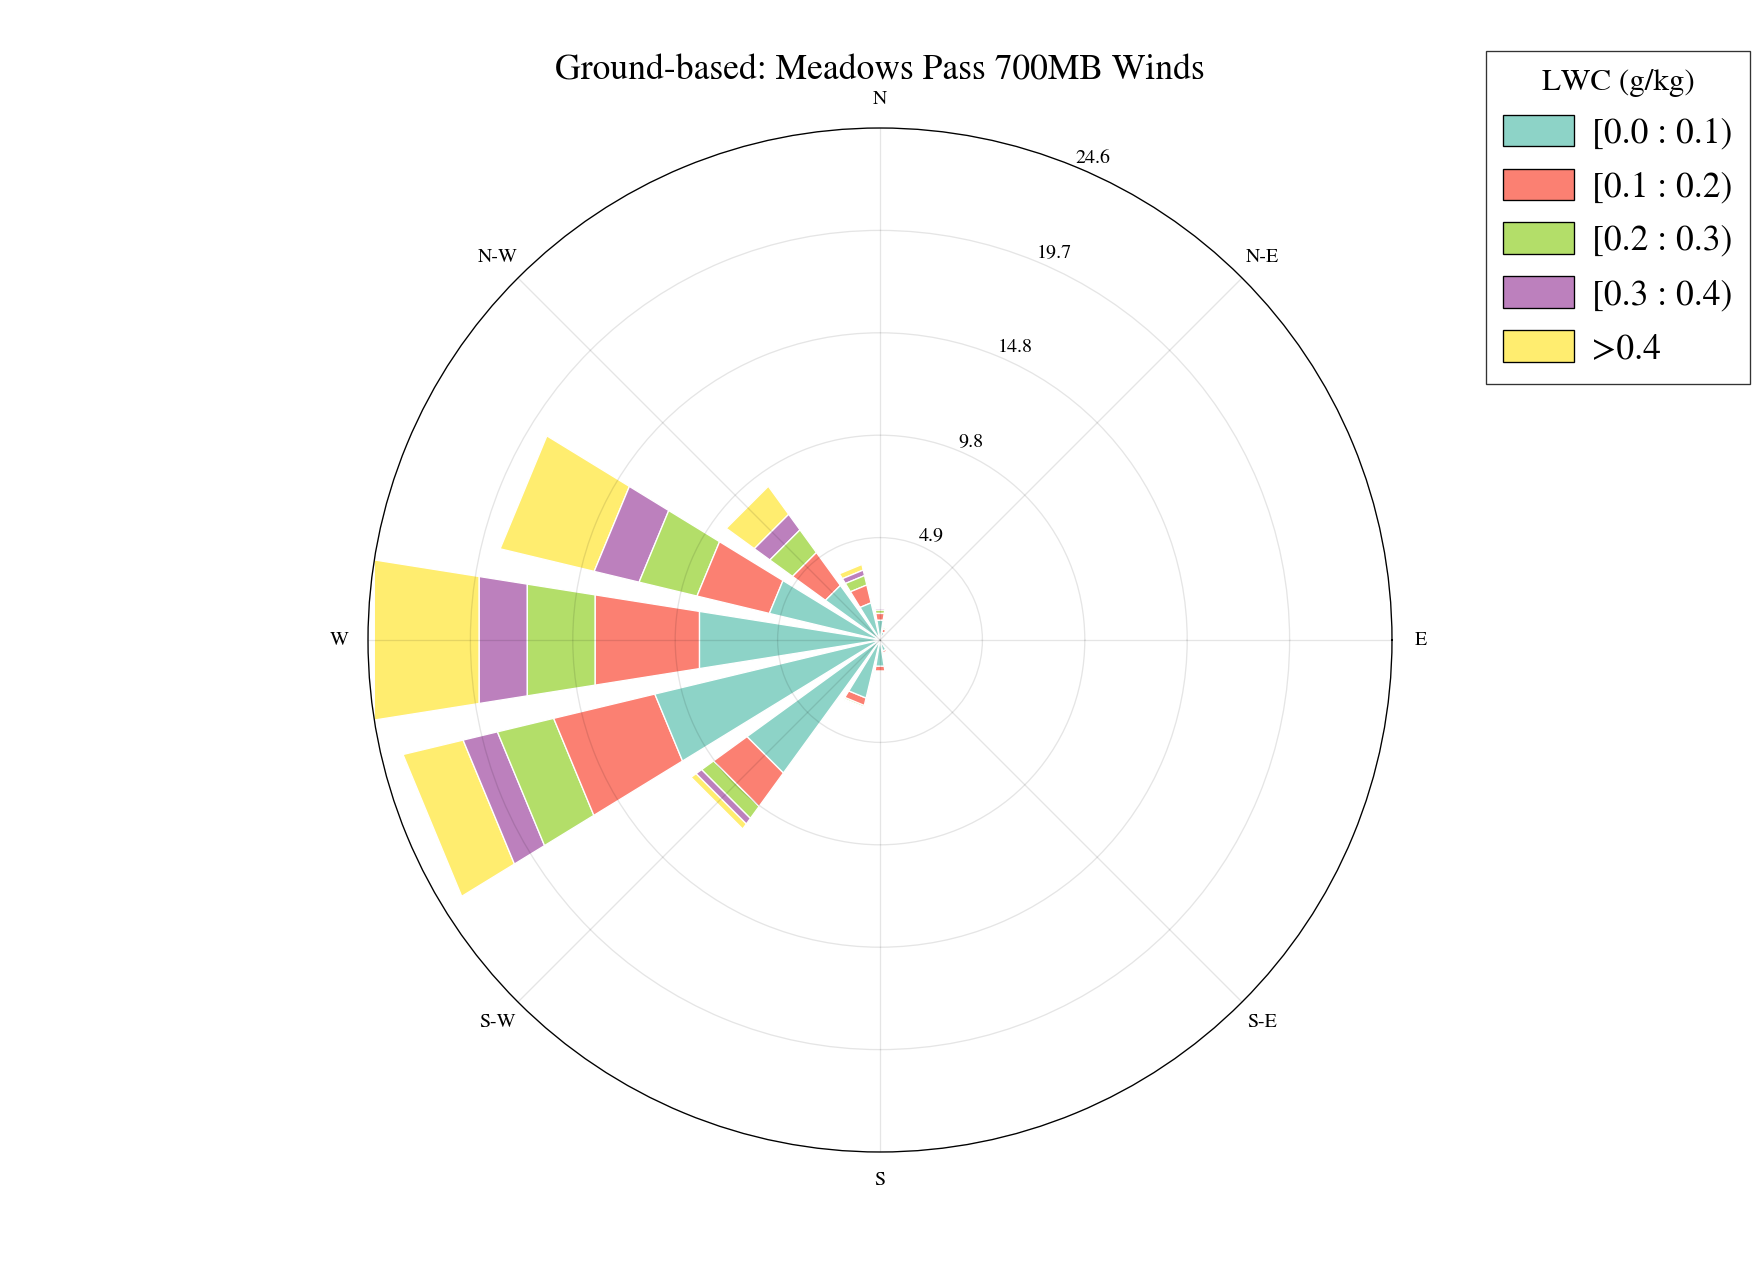

Saving windrose image to: "/Users/meghan/Roza/roza3/roza/figures/windroses/groundslw_windrose/Ground_based_Sasse_Ridge_700MB_Winds_Windrose.png"


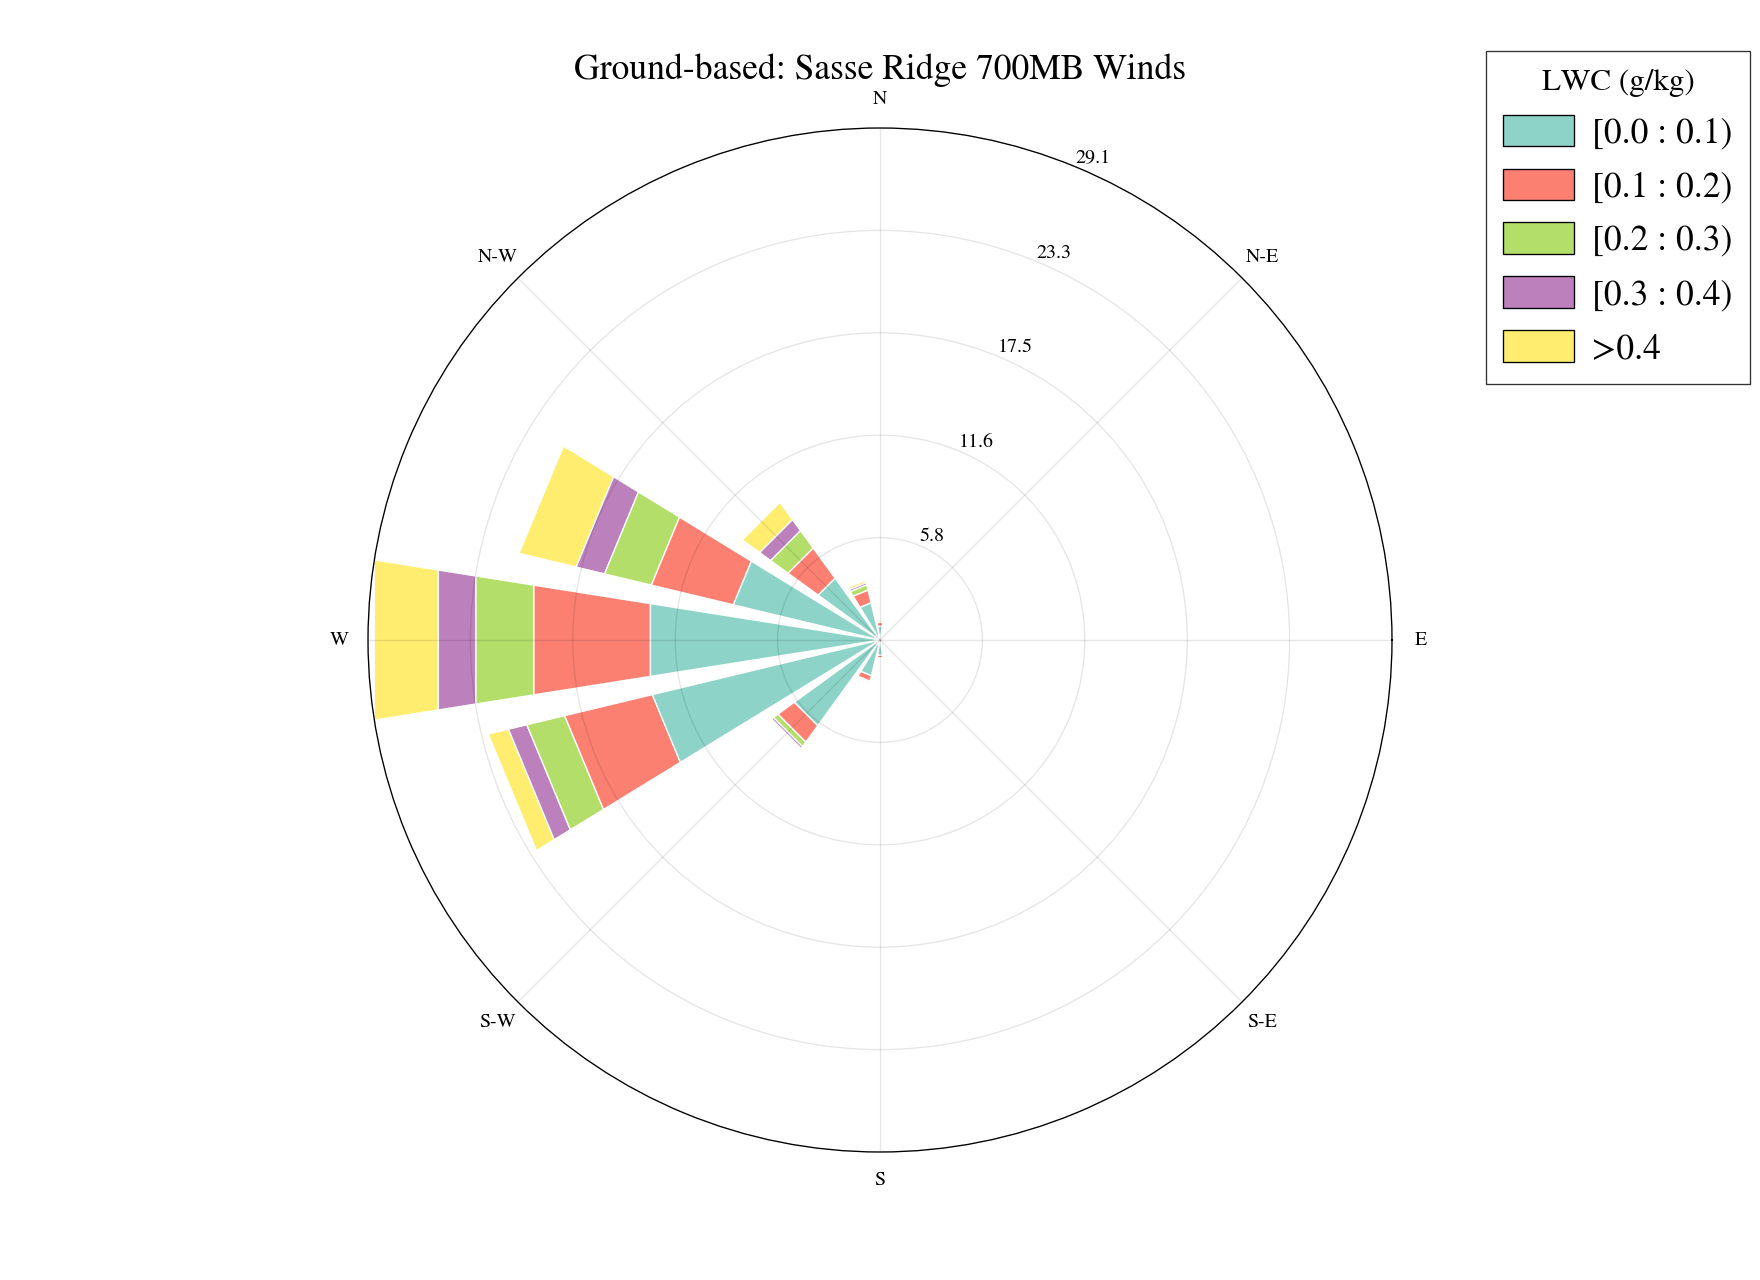

In [37]:
#Plot windroses by SLW - Ground 
def groundslw_windrose(filepath=None, name=None):
    filepath = filepath if os.path.exists(filepath) else os.path.join('windrose_data', filepath)
    ds = xr.open_dataset(filepath, engine = 'netcdf4')
    df = ds[['U_700MB','V_700MB','GS_LWC']].to_dataframe()
    df=df[df['GS_LWC']>0.01]
    df.U_700MB[df.U_700MB > 999] = np.nan
    df.V_700MB[df.V_700MB > 999] = np.nan
    df['WSPD'] = np.sqrt(df.U_700MB**2+df.V_700MB**2)
    df['WDIR'] = np.arctan2(df.U_700MB.values,df.V_700MB.values)*180/math.pi+180;
    df.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    speed =df.WSPD
    dir = df.WDIR

    # colormap = plt.get_cmap('batlow')
    colormap = plt.get_cmap('set3')
    ax = WindroseAxes.from_ax()
    # ax.set_xticklabels(['N','NE','E','SE','S','SW','W','NW'],fontsize=14)
    # ax.set_yticklabels([],fontsize=14)
    ax.bar(df.WDIR,df.GS_LWC, normed = True, opening=0.8, edgecolor='white', bins = np.arange(0,.5,0.1),cmap = colormap)

    
    ax.set_legend()
    ax.set_title(name,fontsize=16)
    ax.legend(title='LWC (g/kg)',loc = 4, bbox_to_anchor=[1.35, 0.75],fontsize=16, title_fontsize=14)
    

    # ax.set_yticks(np.arange(10, 40, step=10))
    # ax.set_yticklabels(np.arange(10, 40, step=10))
    fig = plt.gcf()
    fig.set_size_inches(11, 8)

    # ax.set_yticks(np.arange(10, 40, step=10))
    # ax.set_yticklabels(np.arange(10, 40, step=10))

    #matplotlib.pyplot.savefig(os.path.join('precip_windrose',"{} Precip Windrose.png".format(name.replace(' ','_'))), dpi=300, transparent=False)
    #matplotlib.pyplot.close()
    output_name="{}_Windrose.png".format(name.replace('-','_').replace(':','').replace('(','').replace(')','').replace(' ','_'))
    output_file=os.path.join(output_path, 'groundslw_windrose', output_name)
    print(f'Saving windrose image to: "{output_file}"')
    matplotlib.pyplot.savefig(output_file, dpi=300, transparent=False)
    matplotlib.pyplot.show()
    
_=[groundslw_windrose(**dd) for dd in groundfiles]



In [ ]:
#Plot windroses by precipitation
def precip_windrose(filepath=None, name=None):
    filepath = filepath if os.path.exists(filepath) else os.path.join('windrose_data', filepath)
    ds = xr.open_dataset(filepath, engine = 'netcdf4')
    df = ds[['U_700MB','V_700MB','PREC_ACC_NC']].to_dataframe()
    df=df[df['PREC_ACC_NC']>0]
    df.U_700MB[df.U_700MB > 999] = np.nan
    df.V_700MB[df.V_700MB > 999] = np.nan
    df['WSPD'] = np.sqrt(df.U_700MB**2+df.V_700MB**2)
    df['WDIR'] = np.arctan2(df.U_700MB.values,df.V_700MB.values)*180/math.pi+180;
    df.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    speed =df.WSPD
    dir = df.WDIR

    colormap = plt.get_cmap('hawaii')
    ax = WindroseAxes.from_ax()
    ax.bar(df.WDIR,df.PREC_ACC_NC, normed = True, opening=0.8, edgecolor='white', bins = np.arange(0,1,0.2),cmap = colormap)

    
    ax.set_legend()
    ax.set_title(name)
    ax.legend(title='Precipitation (mm)',loc = 4)

    # ax.set_yticks(np.arange(10, 40, step=10))
    # ax.set_yticklabels(np.arange(10, 40, step=10))

    # matplotlib.pyplot.savefig(os.path.join('precip_windrose',"{} Precip Windrose.png".format(name.replace(' ','_'))), dpi=300, transparent=False)
    #matplotlib.pyplot.close()output_name="{}_Windrose.png".format(name.replace('-','_').replace(':','').replace('(','').replace(')','').replace(' ','_'))
    output_name="{}_Windrose.png".format(name.replace('-','_').replace(':','').replace('(','').replace(')','').replace(' ','_'))
    output_file=os.path.join(output_path, 'precip_windrose', output_name)
    print(f'Saving windrose image to: "{output_file}"')
    matplotlib.pyplot.savefig(output_file, dpi=300, transparent=False)
    matplotlib.pyplot.show()
    
# _=[precip_windrose(**dd) for dd in precipfiles]


In [ ]:
#Transparent Windrose
def precip_windrose(filepath=None, name=None):
    filepath = filepath if os.path.exists(filepath) else os.path.join('windrose_data', filepath)
    ds = xr.open_dataset(filepath, engine = 'netcdf4')
    df = ds[['U_700MB','V_700MB','PREC_ACC_NC']].to_dataframe()
    df=df[df['PREC_ACC_NC']>0]
    df.U_700MB[df.U_700MB > 999] = np.nan
    df.V_700MB[df.V_700MB > 999] = np.nan
    df['WSPD'] = np.sqrt(df.U_700MB**2+df.V_700MB**2)
    df['WDIR'] = np.arctan2(df.U_700MB.values,df.V_700MB.values)*180/math.pi+180;
    df.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    speed =df.WSPD
    dir = df.WDIR

    colormap = plt.get_cmap('glacial')
    ax = WindroseAxes.from_ax()
    ax.bar(df.WDIR,df.WSPD, normed = True, opening=0.8, edgecolor='white', bins = 10,cmap = colormap)

    
    # ax.set_legend()
    ax.set_title(name)
    # ax.legend(title='Wind Speed (m/s))',loc = 4)

    # ax.set_yticks(np.arange(10, 40, step=10))
    # ax.set_yticklabels(np.arange(10, 40, step=10))

    #matplotlib.pyplot.savefig(os.path.join('precip_windrose',"{} Precip Windrose.png".format(name.replace(' ','_'))), dpi=300, transparent=False)
    #matplotlib.pyplot.close()
    matplotlib.pyplot.show()
    
# _=[precip_windrose(**dd) for dd in files]


In [ ]:
#Data Files for Basin Windroses
files2=[
    
    {'filepath':'/Users/meghan/Montana/Montana_Masks/area_avgs/wr1.nc','name':'Wind Rose 1 700MB Winds'},
    {'filepath':'/Users/meghan/Montana/Montana_Masks/area_avgs/wr2.nc','name':'Wind Rose 2 700MB Winds'},
    {'filepath':'/Users/meghan/Montana/Montana_Masks/area_avgs/wr3.nc','name':'Wind Rose 3 700MB Winds'},
    {'filepath':'/Users/meghan/Montana/Montana_Masks/area_avgs/wr4.nc','name':'Wind Rose 4 700MB Winds'},
    {'filepath':'/Users/meghan/Montana/Montana_Masks/area_avgs/wr5.nc','name':'Wind Rose 5 700MB Winds'},
    {'filepath':'/Users/meghan/Montana/Montana_Masks/masks/windrosesites/wr6.nc','name':'Wind Rose 6 700MB Winds'},

 
    ]

In [ ]:
#Transparent Windrose
def basin_windrose(filepath=None, name=None):
    filepath = filepath if os.path.exists(filepath) else os.path.join('windrose_data', filepath)
    ds = xr.open_dataset(filepath, engine = 'netcdf4')
    df = ds[['U_700MB','V_700MB','PREC_ACC_NC']].to_dataframe()
    df=df[df['PREC_ACC_NC']>0]
    df.U_700MB[df.U_700MB > 999] = np.nan
    df.V_700MB[df.V_700MB > 999] = np.nan
    df['WSPD'] = np.sqrt(df.U_700MB**2+df.V_700MB**2)
    df['WDIR'] = np.arctan2(df.U_700MB.values,df.V_700MB.values)*180/math.pi+180;
    df.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    speed =df.WSPD
    dir = df.WDIR

    colormap = plt.get_cmap('glacial')
    ax = WindroseAxes.from_ax()
    ax.bar(df.WDIR,df.WSPD, normed = True, opening=0.8, edgecolor='white', bins = 10,cmap = colormap)

    
    # ax.set_legend()
    ax.set_title(name)
    # ax.legend(title='Wind Speed (m/s))',loc = 4)

    # ax.set_yticks(np.arange(10, 40, step=10))
    # ax.set_yticklabels(np.arange(10, 40, step=10))

    #matplotlib.pyplot.savefig(os.path.join('precip_windrose',"{} Precip Windrose.png".format(name.replace(' ','_'))), dpi=300, transparent=False)
    #matplotlib.pyplot.close()
    matplotlib.pyplot.show()
    
_=[basin_windrose(**dd) for dd in files2]
